# MSIN0097: Predictive Analytics  
## Individual Assignment

**Title:** Predicting Online Purchase Intent: A Session-Level Classification Approach  
**Dataset:** Online Shoppers Purchasing Intention  
**Candidate Number:** VSVJ0

## Table of Contents
- 0. Environment Setup & Reproducibility
  - 0.1 Library Imports
  - 0.2 Configuration & Random Seed
  - 0.3 Helper Functions
- 1. Problem Framing & Agent Planning
  - 1.1 Business Context: Real-time Coupon Targeting
  - 1.2 Prediction Task Definition
  - 1.3 Success Metrics & Justification (PR-AUC vs Accuracy)
  - 1.4 Agent Tooling Plan (Delegation vs Verification)
- 2. Data Loading & Initial Validation
  - 2.1 Load Dataset
  - 2.2 Shape, Dtypes, Head
  - 2.3 Missing Value Check
  - 2.4 Target Distribution
  - 2.5 Basic Statistics
  - 2.6 Data Integrity Checks
- 3. Exploratory Data Analysis (EDA)
  - 3.1 Class Imbalance Analysis
  - 3.2 Temporal Patterns
  - 3.3 PageValues Analysis & Leakage Check
  - 3.4 Zero-Inflation & Distribution Analysis
  - 3.5 Correlation Analysis & Multicollinearity
  - 3.6 EDA Summary & Preprocessing Considerations
- 4. Data Preparation, Leakage Control & Reproducible Pipeline
  - 4.1 Feature-Target Separation
  - 4.2 Stratified Train/Validation/Test Split (70/15/15)
  - 4.3 Preprocessing Pipeline Design
  - 4.4 Class Imbalance Strategy: SMOTE vs Class Weights
  - 4.5 Post-split Validation Checks
- 5. Modelling: Baseline and Candidate Model Evaluation
  - 5.1 Evaluation Framework
  - 5.2 Baseline Model: Logistic Regression
  - 5.3 Candidate Model 1: Random Forest
  - 5.4 Candidate Model 2: XGBoost
  - 5.5 Candidate Model 3: Multi-Layer Perceptron (MLP)
  - 5.6 Model Comparison and Selection
- 6. Fine-Tuning & Threshold Optimisation
  - 6.1 Hyperparameter Tuning Strategy (Optuna)
    - 6.1.1 Hyperparameter Search Space
    - 6.1.2 Optuna Objective Function
    - 6.1.3 Optuna Study Setup & Results
    - 6.1.4 Best Hyperparameters Selection
  - 6.2 Validation Curve Analysis
    - 6.2.1 Validation Curve: max_depth
    - 6.2.2 Validation Curve: n_estimators
    - 6.2.3 Validation Curve: learning_rate
    - 6.2.4 Validation Curve Summary
  - 6.3 Threshold Optimisation
    - 6.3.1 Threshold Evaluation Strategy
    - 6.3.2 Threshold Sweep and Metric Evaluation
    - 6.3.3 Selected Threshold and Interpretation
- 7. Final Evaluation on Test Set
  - 7.1 Final Test Performance
  - 7.2 ROC and Precision-Recall Curves
  - 7.3 Confusion Matrix at Selected Threshold
  - 7.4 Probability Calibration for Decision Readiness
    - 7.4.1 Calibration Curve (Test Set)
    - 7.4.2 Brier Score Assessment
  - 7.5 Model Explainability: SHAP Analysis
    - 7.5.1 SHAP Global Feature Importance
    - 7.5.2 SHAP Summary Plot
    - 7.5.3 SHAP Dependence Plot
  - 7.6 Failure Mode Analysis and Risk Interpretation
    - 7.6.1 Error Counts and Numeric Summary
    - 7.6.2 Feature-Level Comparison (FP vs FN)
    - 7.6.3 Categorical Pattern Analysis
- 8. Model Card
  - 8.1 Intended Use & Out-of-Scope Use
  - 8.2 Data Provenance & Constraints
  - 8.3 Performance Summary & Caveats
  - 8.4 Limitations and Risks
- 9. Reflection on Agent Use & Verification
  - 9.1 Summary of Agent Contributions
  - 9.2 Agent Mistakes Caught and Corrected
  - 9.3 Accepted Agent Contributions
  - 9.4 Critical Assessment and Human Judgement

# 0. Environment Setup & Reproducibility

## 0.1 Library Imports

In [1]:
# Standard library
import os
import random
import warnings

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn — pipeline & preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# Scikit-learn — models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Scikit-learn — evaluation & calibration
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_curve, 
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    brier_score_loss,
)
from sklearn.calibration import CalibrationDisplay, calibration_curve

# Scikit-learn — class imbalance utilities
from sklearn.utils.class_weight import compute_sample_weight

# XGBoost
from xgboost import XGBClassifier

# Imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Hyperparameter optimisation
import optuna
from optuna.samplers import TPESampler

# Explainability
import shap

# Global settings
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Libraries imported.")

Libraries imported.


## 0.2 Configuration & Random Seed

In [2]:
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DATA_PATH  = "online_shoppers_intention.csv"
FIG_DIR    = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Global plot style — applied once, inherited by all figures
plt.rcParams.update({
    "figure.dpi":        150,
    "figure.facecolor":  "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "legend.fontsize":   10,
})

# Consistent colour encoding for the binary target throughout the notebook
PALETTE = {
    "False": "#4C9BE8", "True":  "#E8694C",
    False:   "#4C9BE8",  True:   "#E8694C",
}

print(f"RANDOM_STATE = {RANDOM_STATE} | Figures → ./{FIG_DIR}/")

RANDOM_STATE = 42 | Figures → ./figures/


## 0.3 Helper Functions

In [3]:
def save_fig(filename: str, dpi: int = 150) -> None:
    """Save the current figure to FIG_DIR."""
    plt.savefig(os.path.join(FIG_DIR, filename), dpi=dpi, bbox_inches="tight")
    print(f"  Saved: {filename}")


def evaluate_model_quick(
    model,
    X: np.ndarray,
    y: np.ndarray,
    threshold: float = 0.5,
    label: str = "",
) -> dict:
    """
    Lightweight evaluation helper for early-stage checks.
    """
    y_true = np.asarray(y).astype(int)
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "Label":     label,
        "PR-AUC":    round(average_precision_score(y_true, y_prob),     4),
        "ROC-AUC":   round(roc_auc_score(y_true, y_prob),               4),
        "F1":        round(f1_score(y_true, y_pred, zero_division=0),   4),
        "Brier":     round(brier_score_loss(y_true, y_prob),            4),
        "Threshold": threshold,
    }


def find_optimal_threshold(model, X_val: np.ndarray, y_val: np.ndarray) -> float:
    """
    Return the threshold that maximises F1 on the validation set.
    """
    y_true = np.asarray(y_val).astype(int)
    y_prob = model.predict_proba(X_val)[:, 1]
    prec, rec, thresholds = precision_recall_curve(y_true, y_prob)

    f1s = np.where(
        (prec[:-1] + rec[:-1]) == 0,
        0,
        2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1]),
    )
    best_idx = int(np.argmax(f1s))
    best_thr = float(thresholds[best_idx])
    print(f"  Optimal threshold: {best_thr:.3f}  (val F1 = {f1s[best_idx]:.4f})")
    return best_thr


def plot_confusion_matrix_custom(
    y_true,
    y_pred,
    title: str = "Confusion Matrix",
    filename: str | None = None,
) -> None:
    """Confusion matrix with absolute counts and row-normalised percentages.
    Uses row-normalised values for colour mapping so minority-class cells
    are always visible regardless of class imbalance.
    """
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    cm = confusion_matrix(y_true, y_pred)

    # Row-normalise for colour mapping only (each row sums to 1)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1, row_sums)
    cm_norm = cm / row_sums        # used only for colour scale
    cm_pct  = cm_norm * 100        # percentage labels

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm_norm,
        annot=False,
        cmap="Blues",
        vmin=0, vmax=1,
        linewidths=0.5,
        xticklabels=["No Purchase", "Purchase"],
        yticklabels=["No Purchase", "Purchase"],
        ax=ax,
        cbar_kws={"label": "Row proportion"},
    )

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            text_color = "white" if cm_norm[i, j] > 0.5 else "black"
            ax.text(
                j + 0.5, i + 0.5,
                f"{cm[i, j]}\n({cm_pct[i, j]:.1f} %)",
                ha="center", va="center",
                fontsize=11, fontweight="bold",
                color=text_color,
            )

    ax.set_xlabel("Predicted", fontweight="bold")
    ax.set_ylabel("Actual",    fontweight="bold")
    ax.set_title(title, pad=12)
    plt.tight_layout()
    if filename:
        save_fig(filename)
    plt.show()

# 1. Problem Framing & Agent Planning

## 1.1 Business Context: Real-time Coupon Targeting

An e-commerce platform currently issues discount coupons to all visitors, no matter how likely they are to buy. This broad strategy wastes budget on sessions that would have converted anyway, and it fails to support borderline visitors who need a small push.

A session-level binary classifier solves this problem by scoring each active visit in real time. If a session’s predicted purchase probability is above a business-set threshold, it receives a targeted coupon. If it is below the threshold, it does not.

From this setup, two types of error costs arise, and they influence all later modelling decisions, such as metric choice, class imbalance handling, threshold selection, and error analysis:

| Error type | Business consequence |
|---|---|
| **False Positive** | Coupon pushed to a non-buyer → wasted discount spend |
| **False Negative** | No coupon for a buyer → missed conversion / lost revenue |

## 1.2 Prediction Task Definition

| Attribute | Detail |
|---|---|
| **Target variable** | `Revenue` (bool → int; 1 = purchase, 0 = no purchase) |
| **Task** | Binary classification |
| **Prediction unit** | Individual browsing session |
| **Assumption** | Sessions treated as independent observations; repeat visits by the same user are not linked |

**Behavioural features — numerical (10)**  
`Administrative`, `Administrative_Duration`, `Informational`, `Informational_Duration`,  
`ProductRelated`, `ProductRelated_Duration`, `BounceRates`, `ExitRates`, `PageValues`, `SpecialDay`

**Contextual features — categorical / boolean (7)**  
`Month`, `VisitorType`, `Weekend`, `OperatingSystems`, `Browser`, `Region`, `TrafficType`

*Source: UCI ML Repository — Online Shoppers Purchasing Intention. 12,330 sessions | 17 features | 1 binary target.*

## 1.3 Success Metrics & Justification (PR-AUC vs Accuracy)

| Metric | Role | Rationale |
|------|------|-----------|
| **PR-AUC** | Primary | Robust to class imbalance and directly evaluates the ranking quality of positive sessions, which aligns with the business objective of efficient coupon targeting. |
| **F1-score** | Secondary | Evaluated after threshold optimisation to reflect the balance between precision and recall at the decision stage. |
| **ROC-AUC** | Supporting | Threshold-independent metric used for consistent cross-model comparison. |

**Why not accuracy?**  
In this dataset, positive sessions account for approximately 15% of all observations.  
Under such class imbalance, a naive all-negative classifier achieves around 85% accuracy while providing no meaningful predictive value.

Accuracy therefore fails to capture model usefulness in this setting and is excluded from all evaluations.  
Instead, imbalance-aware metrics are used throughout the analysis, as formalised later in the unified evaluation framework (Section 5.1).

## 1.4 Agent Tooling Plan (Delegation vs Verification)

To accelerate implementation while maintaining rigorous methodological control, 
an AI coding assistant (Codex) was utilised. The following table establishes 
the explicit boundary between delegated drafting and human verification, 
addressing the Step 1 requirement of this coursework.

| Task Category | Delegated to Agent | Reviewed / Considered Independently |
| :--- | :--- | :--- |
| **Data & Pipeline** | Boilerplate scaling & OHE code | Leakage sensitivity review (`PageValues`) and transformation options (e.g., `log1p`) |
| **Modelling** | Scaffold for model comparison | Metric selection (PR-AUC) and baseline definition |
| **Evaluation** | Confusion matrix plotting utilities | Threshold optimisation logic |
| **Hyperparameters** | Optuna objective function structure | Search space bounds and overfitting risk |

*The actual execution, including agent mistakes caught and corrected, is 
documented in the Agent Usage Log (Appendix A) and Section 9.*

# 2. Data Loading & Initial Validation

## 2.1 Load Dataset

In [48]:
df = pd.read_csv(DATA_PATH)

## 2.2 Shape, Dtypes, Head

This section provides a concise structural overview of the dataset.
A small sample of rows is displayed to verify feature semantics and value ranges,
followed by a summary of dataset dimensionality.

In [5]:
# Display a small sample of the dataset for structural inspection
display(df.head())

# Extract basic dimensionality information
n_rows, n_cols = df.shape
n_features = n_cols - 1  # exclude target variable

print(
    f"The dataset contains {n_rows:,} sessions "
    f"with {n_features} input features "
    f"and 1 binary target variable (Revenue)."
)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


The dataset contains 12,330 sessions with 17 input features and 1 binary target variable (Revenue).


## 2.3 Missing Value Check

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
display(missing)

n_missing_total = int(missing.sum())
if n_missing_total == 0:
    print("No missing values were observed across any features, so no imputation was required and all sessions were retained.")
else:
    print(f"Missing values detected: {n_missing_total} total missing entries.")

Administrative             0
Administrative_Duration    0
Weekend                    0
VisitorType                0
TrafficType                0
Region                     0
Browser                    0
OperatingSystems           0
Month                      0
SpecialDay                 0
PageValues                 0
ExitRates                  0
BounceRates                0
ProductRelated_Duration    0
ProductRelated             0
Informational_Duration     0
Informational              0
Revenue                    0
dtype: int64

No missing values were observed across any features, so no imputation was required and all sessions were retained.


## 2.4 Target Distribution

In [7]:
target_counts = df["Revenue"].value_counts(dropna=False)
target_rates = df["Revenue"].value_counts(normalize=True, dropna=False)

display(target_counts.to_frame("count"))
display(target_rates.to_frame("proportion"))

,count
Revenue,
False,10422
True,1908


,proportion
Revenue,
False,0.845255
True,0.154745


## 2.5 Basic Statistics

In [8]:
display(df.describe(include="all"))

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330,12330.000000,12330.000000,12330.000000,12330.000000,12330,12330,12330
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,NaN,3,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,May,NaN,NaN,NaN,NaN,Returning_Visitor,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3364,NaN,NaN,NaN,NaN,10551,9462,10422
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,NaN,2.124006,2.357097,3.147364,4.069586,NaN,NaN,NaN
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,NaN,0.911325,1.717277,2.401591,4.025169,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,NaN,2.000000,2.000000,1.000000,2.000000,NaN,NaN,NaN
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,NaN,2.000000,2.000000,3.000000,2.000000,NaN,NaN,NaN
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,NaN,3.000000,2.000000,4.000000,4.000000,NaN,NaN,NaN


## 2.6  Data Integrity Checks

In [9]:
# Intent: Validate that basic structural and range assumptions hold before deeper analysis.

# 1) Row count check
assert df.shape[0] == 12330, "Unexpected number of rows."

# 2) Fully duplicated rows (diagnostic)
n_duplicates = int(df.duplicated().sum())
print(f"Duplicate rows detected: {n_duplicates}")

# 3) Rate-based range checks
assert df["BounceRates"].between(0, 1).all(), "BounceRates out of range [0, 1]."
assert df["ExitRates"].between(0, 1).all(), "ExitRates out of range [0, 1]."

# 4) Non-negative checks for duration-based features (diagnostic + interpretation)
duration_cols = [
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration",
]

neg_counts = (df[duration_cols] < 0).sum()
display(neg_counts.to_frame("n_negative"))

n_neg_total = int(neg_counts.sum())
if n_neg_total == 0:
    print("No negative values were found in duration-based features.")
else:
    print(f"Negative duration values found: {n_neg_total} entries.")

Duplicate rows detected: 125


,n_negative
Administrative_Duration,0
Informational_Duration,0
ProductRelated_Duration,0


No negative values were found in duration-based features.


Basic integrity checks were conducted to confirm the structural validity of the dataset prior to analysis.
A small number of fully duplicated rows were observed; however, in the absence of a unique session identifier, these may reflect distinct sessions with identical behavioural patterns rather than data errors, so all observations were retained.
All rate-based features fell within valid ranges, and no negative values were found in duration-based variables.

# 3. Exploratory Data Analysis (EDA)

## 3.1 Class Imbalance Analysis

  Saved: fig03_1_class_imbalance


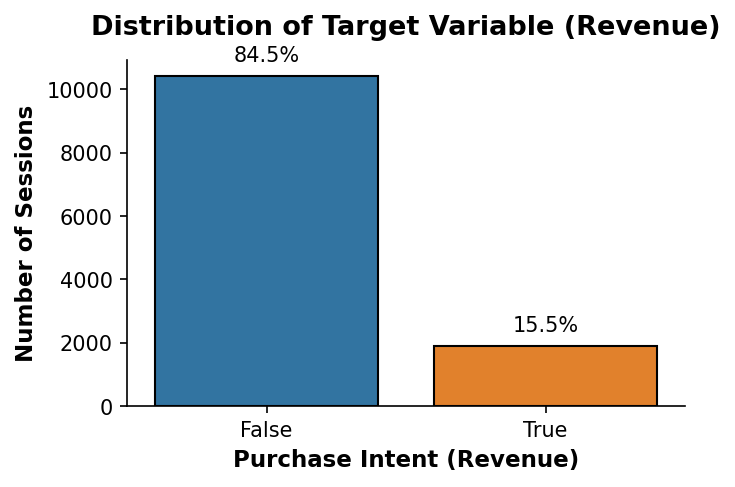

In [10]:
fig, ax = plt.subplots(figsize=(4.8, 3))

sns.countplot(
    x="Revenue",
    data=df,
    order=[False, True],
    ax=ax,
    edgecolor="black",
    linewidth=1
)

ax.set_title("Distribution of Target Variable (Revenue)", pad=12, fontweight="bold")
ax.set_xlabel("Purchase Intent (Revenue)", fontweight="bold")
ax.set_ylabel("Number of Sessions", fontweight="bold")

total = len(df)
for p in ax.patches:
    pct = 100 * p.get_height() / total
    ax.annotate(
        f"{pct:.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points"
    )

save_fig("fig03_1_class_imbalance")
plt.show()

The target variable shows a clear class imbalance, with purchase sessions accounting for approximately 15.5% of all observations.

Because of this imbalance, accuracy would be misleading as a primary metric. Instead, PR-AUC and F1-score are used in later sections, and imbalance-aware strategies such as class weighting and SMOTE are evaluated during model training.

## 3.2 Temporal Patterns

  Saved: fig03_2_temporal_heatmap


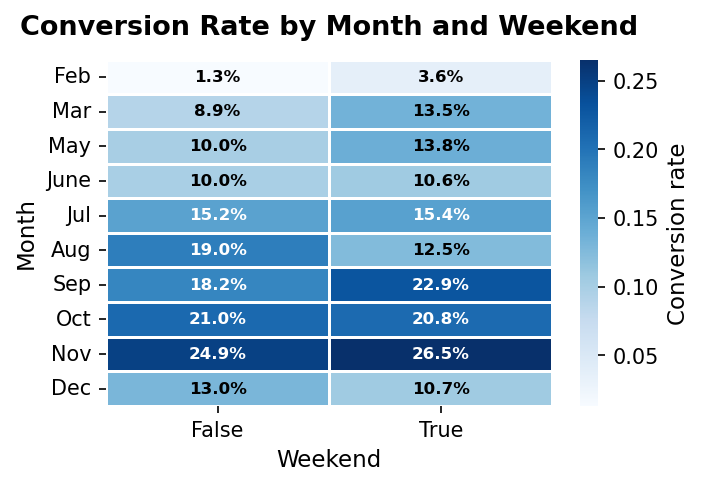

,n_sessions
Month,
Feb,184
Mar,1907
May,3364
June,288
Jul,432
Aug,433
Sep,448
Oct,549
Nov,2998


In [11]:
# Arrange months in calendar order for readability
calendar_months = ["Jan", "Feb", "Mar", "Apr", "May", "June",
                   "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
present_months = [m for m in calendar_months if m in df["Month"].unique()]
df_plot = df.copy()
df_plot["Month"] = pd.Categorical(
    df_plot["Month"], categories=present_months, ordered=True
)

# Compute mean Revenue (= conversion rate) by Month × Weekend
pivot = df_plot.pivot_table(
    index="Month",
    columns="Weekend",
    values="Revenue",
    aggfunc="mean"
)
pivot = pivot.reindex(columns=[False, True])

fig, ax = plt.subplots(figsize=(4.8, 3))
sns.heatmap(
    pivot,
    annot=False,
    cmap="Blues",
    cbar_kws={"label": "Conversion rate"},
    linewidths=0.5,
    linecolor="white",
    ax=ax
)

# Annotate cells manually to ensure text visibility across all colour intensities
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.iloc[i, j]
        if not np.isnan(val):
            text_color = "white" if val > 0.15 else "black"
            ax.text(
                j + 0.5, i + 0.5,
                f"{val:.1%}",
                ha="center", va="center",
                fontsize=8, fontweight="bold",
                color=text_color,
            )

ax.set_title("Conversion Rate by Month and Weekend", pad=12, fontweight="bold")
ax.set_xlabel("Weekend")
ax.set_ylabel("Month")
save_fig("fig03_2_temporal_heatmap")
plt.show()

# Session counts per month to contextualise reliability of conversion rate estimates
month_counts = df_plot["Month"].value_counts().reindex(present_months)
display(month_counts.to_frame("n_sessions"))

In [12]:
# February is visually distinct in the heatmap; quantify its deviation explicitly
feb_mask     = df["Month"] == "Feb"
feb_n        = int(feb_mask.sum())
feb_rate     = df.loc[feb_mask, "Revenue"].mean()
overall_rate = df["Revenue"].mean()

print(f"February      |  n = {feb_n}  |  purchase rate = {feb_rate:.1%}")
print(f"Dataset mean  |              |  purchase rate = {overall_rate:.1%}")

February      |  n = 184  |  purchase rate = 1.6%
Dataset mean  |              |  purchase rate = 15.5%


Conversion rates vary across months, with November and October showing the highest purchase rates, cthough the dataset does not include explicit event labels to confirm this directly. February is a clear outlier: with only 184 sessions and a purchase rate of 1.6%, compared to the dataset average of 15.5%, any pattern estimated for this month is statistically unreliable and should not be treated as representative signal.

Weekend effects are present but inconsistent across months, which supports treating Month and Weekend as separate categorical features rather than encoding them as a single interaction term.

**Modelling Implication**: Both Month and Weekend are retained as categorical inputs. February's small sample size is flagged as a data limitation that may reduce model reliability for that segment, and this is revisited in the conclusion.

## 3.3 PageValues Analysis & Leakage Check

count    12330.000000
mean         5.889258
std         18.568437
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        361.763742
Name: PageValues, dtype: float64

Share of sessions with PageValues == 0: 0.779
  Saved: fig03_3_pagevalues_boxplot


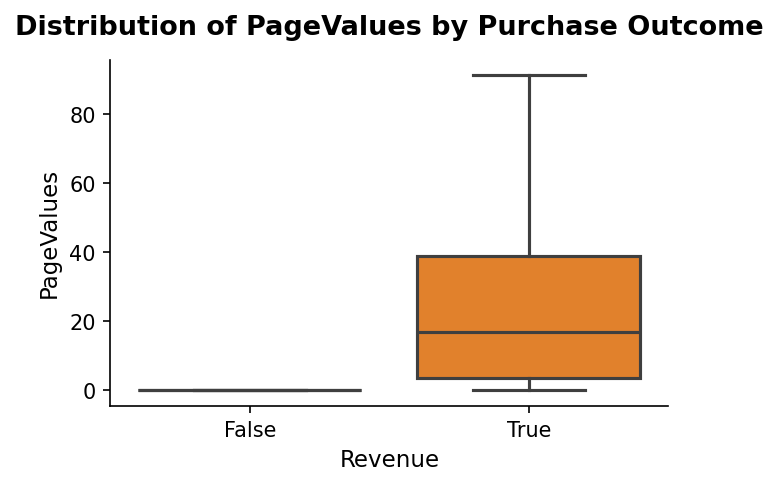

In [13]:
df_plot = df.copy()

# Distribution summary: quantify skewness and zero-concentration
display(df_plot["PageValues"].describe())

pv_zero_share = (df_plot["PageValues"] == 0).mean()
print(f"Share of sessions with PageValues == 0: {pv_zero_share:.3f}")

# Visual comparison of PageValues distribution by purchase outcome
fig, ax = plt.subplots(figsize=(4.8, 3))
sns.boxplot(
    data=df_plot,
    x="Revenue",
    y="PageValues",
    order=[False, True],
    showfliers=False,
    ax=ax
)
ax.set_title("Distribution of PageValues by Purchase Outcome", pad=12, fontweight="bold")
ax.set_xlabel("Revenue")
ax.set_ylabel("PageValues")

save_fig("fig03_3_pagevalues_boxplot")
plt.show()

In [14]:
pv      = df["PageValues"]
revenue = df["Revenue"].astype(int)

# Conversion rate split: zero vs non-zero PageValues
pv_zero_rate    = revenue[pv == 0].mean()
pv_nonzero_rate = revenue[pv  > 0].mean()

print(f"Purchase rate  |  PageValues = 0 : {pv_zero_rate:.1%}")
print(f"Purchase rate  |  PageValues > 0 : {pv_nonzero_rate:.1%}")
print()

# Point-biserial correlation with binary target
pv_corr = pv.corr(revenue)
print(f"Pearson correlation  PageValues ~ Revenue: {pv_corr:.3f}")
print()

# Rank PageValues against all other numerical features by absolute correlation
num_cols_corr = df.select_dtypes(include=["int64", "float64"])
if "Revenue" in num_cols_corr.columns:
    num_cols_corr = num_cols_corr.drop(columns=["Revenue"])

corr_with_target = (
    num_cols_corr
    .apply(lambda col: col.corr(revenue))
    .abs()
    .sort_values(ascending=False)
)
print("Absolute correlation with Revenue (all numerical features):")
display(corr_with_target.to_frame("abs_corr").round(3))

Purchase rate  |  PageValues = 0 : 3.9%
Purchase rate  |  PageValues > 0 : 56.3%

Pearson correlation  PageValues ~ Revenue: 0.493

Absolute correlation with Revenue (all numerical features):


,abs_corr
PageValues,0.493
ExitRates,0.207
ProductRelated,0.159
ProductRelated_Duration,0.152
BounceRates,0.151
Administrative,0.139
Informational,0.095
Administrative_Duration,0.094
SpecialDay,0.082
Informational_Duration,0.070


PageValues shows the strongest association with Revenue among all numerical 
features, with a Pearson correlation of 0.493. The next highest feature, 
ExitRates, has a correlation of 0.207, less than half that of PageValues. 
The separation between segments is substantial: sessions with PageValues 
equal to zero convert at 3.9%, while sessions with positive PageValues 
convert at 56.3%.

Despite this strong signal, PageValues requires an explicit leakage 
assessment. The feature captures the aggregate monetary value of pages 
viewed within a session prior to the purchase event, meaning it reflects 
browsing behaviour that occurs before the outcome is recorded. Within the 
current train–validation split, there is no evidence of target leakage at 
training time, and the feature is retained as a valid input.

**Modelling Implication**: PageValues is expected to be the dominant 
predictor and is retained as a high-signal input. Its predictive dominance 
will be monitored through SHAP analysis in Section 7.5 to confirm it 
reflects genuine pre-purchase intent rather than an artefact of feature 
construction.

## 3.4 Zero-Inflation & Distribution Analysis

In [15]:
zero_rate = (
    (df == 0)
    .mean()
    .sort_values(ascending=False)
)

zero_rate[['Administrative', 'Informational', 'ProductRelated']]

Administrative    0.467802
Informational     0.786618
ProductRelated    0.003082
dtype: float64

  Saved: fig03_4_zero_inflation_distributions


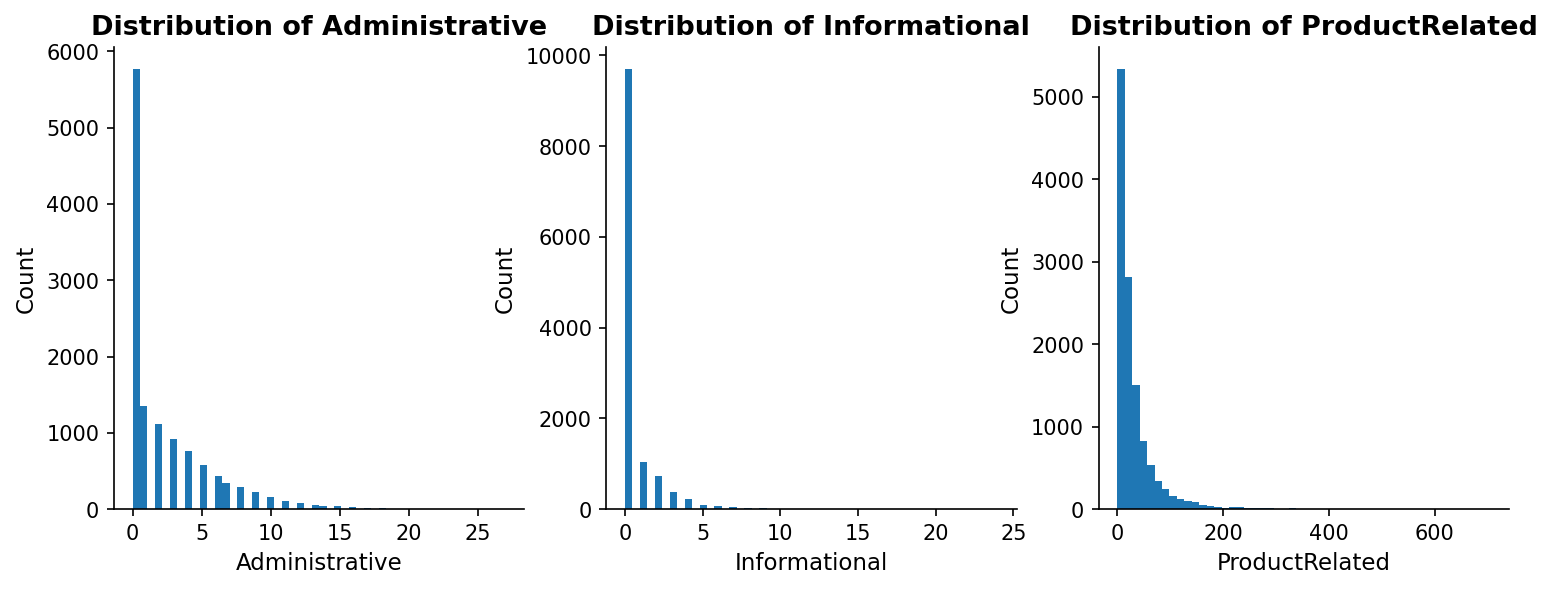

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

features = ['Administrative', 'Informational', 'ProductRelated']

for ax, col in zip(axes, features):
    ax.hist(df[col], bins=50)
    ax.set_title(f"Distribution of {col}", fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

save_fig("fig03_4_zero_inflation_distributions")
plt.show()

In [17]:
duration_cols = [
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration",
]

neg_counts = (df[duration_cols] < 0).sum()
display(neg_counts.to_frame("n_negative"))

assert (neg_counts == 0).all(), "Negative values detected in duration features."

,n_negative
Administrative_Duration,0
Informational_Duration,0
ProductRelated_Duration,0


Several count-based behavioural features show strong zero-inflation and right-skewed distributions. The Informational feature is zero for most sessions, and Administrative also has many zero values. ProductRelated is different, as it has far fewer zeros and a long right tail with a small number of very large values.

These results show that the distributions of these features are uneven. Many observations are concentrated at zero, and the remaining values are spread over a wide range. Because of this, it is not reasonable to treat all count-based features as roughly symmetric.

As an additional check, duration-based features were examined, and no negative values were found. This means that the skewed patterns above reflect actual user behaviour rather than data quality problems.

## 3.5 Correlation Analysis & Multicollinearity

  Saved: fig03_5_correlation_matrix


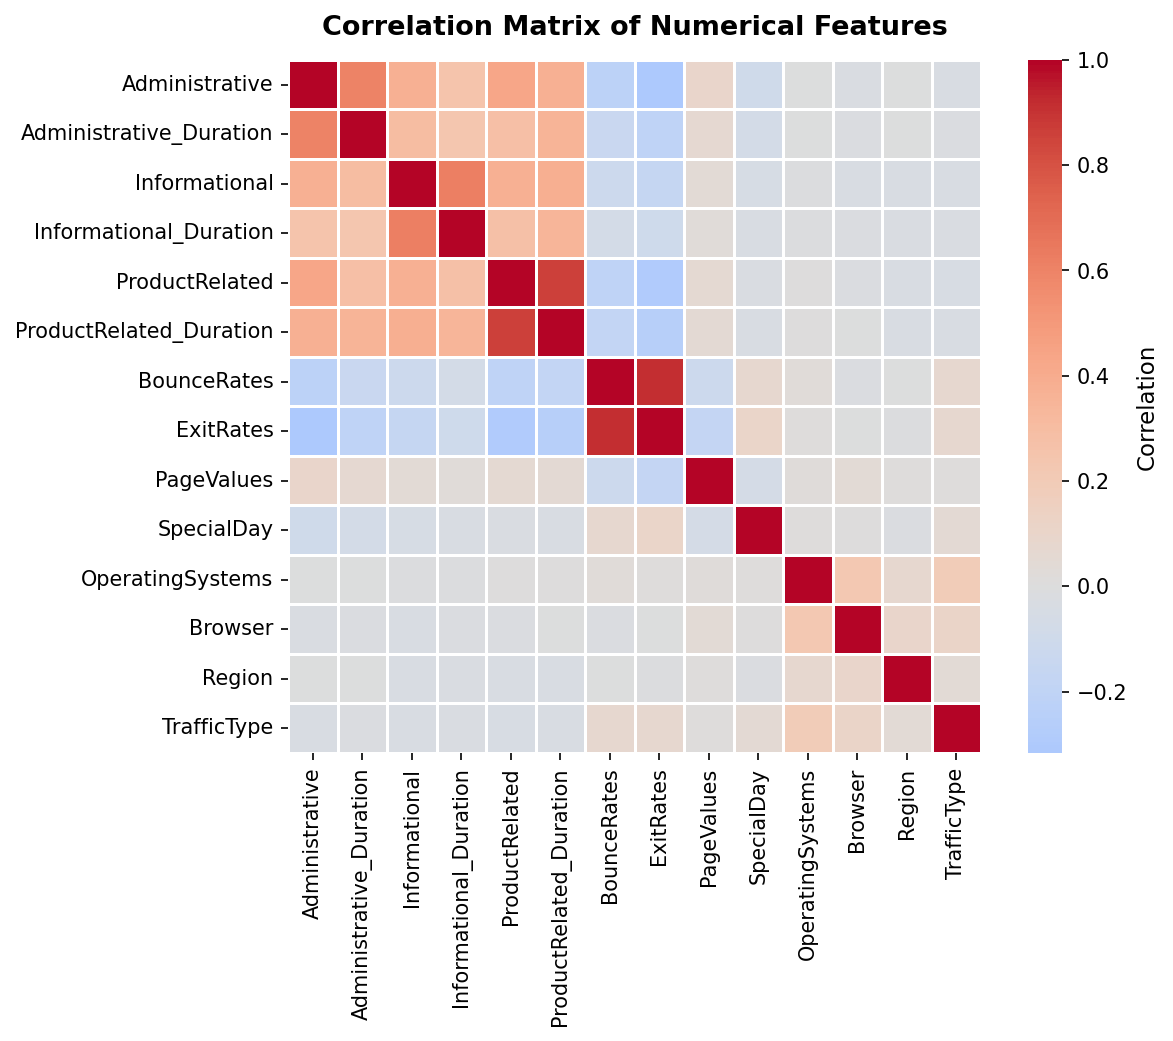

,feature_1,feature_2,abs_corr
91,BounceRates,ExitRates,0.913004
61,ProductRelated,ProductRelated_Duration,0.860927
31,Informational,Informational_Duration,0.618955
1,Administrative,Administrative_Duration,0.601583
4,Administrative,ProductRelated,0.431119
33,Informational,ProductRelated_Duration,0.387505
2,Administrative,Informational,0.376850
32,Informational,ProductRelated,0.374164
5,Administrative,ProductRelated_Duration,0.373939
19,Administrative_Duration,ProductRelated_Duration,0.355422


In [18]:
# Select numerical features
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Correlation matrix
corr_matrix = df[num_cols].corr()

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

ax.set_title("Correlation Matrix of Numerical Features", pad=12, fontweight="bold")
save_fig("fig03_5_correlation_matrix")
plt.show()

# Identify strongly correlated feature pairs
corr_pairs = (
    corr_matrix
    .abs()
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["feature_1", "feature_2", "abs_corr"]

strong_corr = corr_pairs.sort_values("abs_corr", ascending=False)
display(strong_corr.head(10))

Several pairs of numerical features show strong positive correlations. In particular, each count-based feature is highly correlated with its corresponding duration-based feature, which reflects that they measure the same underlying user activity at different scales. A strong correlation is also observed between BounceRates and ExitRates, and this matches their closely related behavioural meanings in web analytics.

Most other feature pairs exhibit weak to moderate correlations. This indicates that potential multicollinearity appears to be limited to a small set of structurally related variables and does not affect the feature set as a whole.

These patterns suggest that the correlations observed here are mainly driven by feature design rather than data quality problems. For this reason, multicollinearity should be considered during model specification, but no immediate feature removal is required at this stage.

## 3.6 EDA Summary & Preprocessing Considerations

- The target (Revenue) is imbalanced, so evaluation should rely on imbalance-aware metrics rather than accuracy alone.
- Month and Weekend show different conversion rates across groups, so they should be treated as categorical or boolean inputs instead of numeric trends.
- PageValues shows a clear separation between purchase and non-purchase sessions in the EDA, so it can be kept as a candidate signal, while potential leakage risk should still be considered.
- Several count and duration features are zero-heavy and right-skewed, so distribution-aware preprocessing may be needed.
- Strong correlations appear in structurally related feature pairs (e.g., counts vs durations, BounceRates vs ExitRates), so multicollinearity should be monitored rather than assumed to be widespread.
- Although several numerical features exhibit heavy tails, extreme values are treated as valid behavioural signals rather than noise. No explicit outlier removal is applied at this stage to avoid distorting high-intent session patterns.

In [19]:
TARGET_COL = "Revenue"

num_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
]

cat_cols = [
    "Month",
    "VisitorType",
]

int_cat_cols = [
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
]

bool_cols = [
    "Weekend",
]

# Sanity check
all_cols = num_cols + cat_cols + int_cat_cols + bool_cols + [TARGET_COL]
missing_cols = [c for c in all_cols if c not in df.columns]
assert len(missing_cols) == 0, f"Missing columns in dataframe: {missing_cols}"

print("Feature groups defined for preprocessing.")
print(
    f"Numerical: {len(num_cols)} | "
    f"Categorical: {len(cat_cols)} | "
    f"Int-coded categorical: {len(int_cat_cols)} | "
    f"Boolean: {len(bool_cols)}"
)

Feature groups defined for preprocessing.
Numerical: 10 | Categorical: 2 | Int-coded categorical: 4 | Boolean: 1


# 4. Data Preparation, Leakage Control & Reproducible Pipeline

## 4.1 Feature–Target Separation

In [20]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

assert X.shape[0] == y.shape[0]

X shape: (12330, 17)
y shape: (12330,)


## 4.2 Stratified Train/Validation/Test Split (70/15/15)

In [21]:
# First split: hold out test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=RANDOM_STATE
)

# Second split: train (70%) and validation (15%)
# 0.1765 ≈ 15 / 85 to preserve overall 70/15/15 ratio
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.1765,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# Split summary
print(f"Train : {X_train.shape[0]:>5} rows | positive rate: {y_train.mean():.4f}")
print(f"Val   : {X_val.shape[0]:>5} rows | positive rate: {y_val.mean():.4f}")
print(f"Test  : {X_test.shape[0]:>5} rows | positive rate: {y_test.mean():.4f}")

# Sanity check: ensure no index overlap across splits
assert len(set(X_train.index) & set(X_val.index)) == 0
assert len(set(X_train.index) & set(X_test.index)) == 0
assert len(set(X_val.index) & set(X_test.index)) == 0

print("No index overlap across splits.")

Train :  8630 rows | positive rate: 0.1548
Val   :  1850 rows | positive rate: 0.1546
Test  :  1850 rows | positive rate: 0.1546
No index overlap across splits.


## 4.3 Preprocessing Pipeline Design

In [22]:
# Use feature groups defined in Section 3.6
num_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

cat_pipeline = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

int_cat_pipeline = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

bool_pipeline = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(drop="if_binary", sparse_output=False))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols),
        ("int_cat", int_cat_pipeline, int_cat_cols),
        ("bool", bool_pipeline, bool_cols),
    ],
    remainder="drop",
)

print("Preprocessing pipeline defined.")

Preprocessing pipeline defined.


Log transformation (e.g., log1p) was considered because strong zero-inflation and right-skewed distributions were observed during exploratory data analysis (EDA). It was not applied for the following reasons:

- Tree-based models (Random Forest and XGBoost) are invariant to monotonic feature transformations, so log transformation is unlikely to change split structure or ranking materially.
- Logistic Regression is included only as a linear baseline, and the additional preprocessing complexity was not justified given its role as a reference model.

As a result, StandardScaler is applied uniformly to numerical features for pipeline consistency.

Numerical imputation was not included in the pipeline because §2.3 confirmed zero missing values across all numerical features. Including an imputer would add unnecessary complexity without analytical benefit.

## 4.4 Class Imbalance Strategy: SMOTE vs Class Weights

In [23]:
y_train_int = y_train.astype(int)
y_val_int   = y_val.astype(int)

# Strategy 1: Baseline (no imbalance handling)
pipe_base = ImbPipeline(steps=[
    ("prep", preprocessor),
    ("clf", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
])
pipe_base.fit(X_train, y_train_int)
res_base = evaluate_model_quick(pipe_base, X_val, y_val_int, label="1) Baseline (unbalanced)")

# Strategy 2: Cost-sensitive learning (class_weight)
pipe_cw = ImbPipeline(steps=[
    ("prep", preprocessor),
    ("clf", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight="balanced")),
])
pipe_cw.fit(X_train, y_train_int)
res_cw = evaluate_model_quick(pipe_cw, X_val, y_val_int, label="2) Class weight (balanced)")

# Strategy 3: Oversampling (SMOTE) — applied inside ImbPipeline
pipe_smote = ImbPipeline(steps=[
    ("prep", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
])
pipe_smote.fit(X_train, y_train_int)
res_smote = evaluate_model_quick(pipe_smote, X_val, y_val_int, label="3) SMOTE (oversampling)")

imbalance_results = (
    pd.DataFrame([res_base, res_cw, res_smote])
      .set_index("Label")
      .sort_values("PR-AUC", ascending=False)
      .round(4)
)

display(imbalance_results)

,PR-AUC,ROC-AUC,F1,Brier,Threshold
Label,,,,,
3) SMOTE (oversampling),0.6535,0.8904,0.6023,0.1158,0.5
2) Class weight (balanced),0.6533,0.8979,0.6145,0.1184,0.5
1) Baseline (unbalanced),0.6437,0.8905,0.4930,0.0862,0.5


Three imbalance handling strategies were evaluated on the validation set: no resampling, SMOTE, and cost-sensitive learning using class weights. All three approaches achieved very similar PR-AUC values, indicating comparable ranking performance under class imbalance.

Although SMOTE and class-weighted learning produced comparable validation PR-AUC, class weighting was selected as the default strategy due to its lower variance, avoidance of synthetic samples, and preservation of the original training distribution. This choice reduces the risk of introducing artificial patterns and results in a simpler and more stable deployment profile for subsequent models.

## 4.5 Post-split Validation Checks

In [24]:
# 1) Pipeline execution + dimensionality consistency
X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep   = preprocessor.transform(X_val)
X_test_prep  = preprocessor.transform(X_test)

assert X_train_prep.shape[1] == X_val_prep.shape[1] == X_test_prep.shape[1], \
    "Feature dimensions do not match across splits."

print(f"Pipeline executed successfully. n_features = {X_train_prep.shape[1]}")

# 2) Target rate check (stratification sanity check)
print(
    f"Positive rate | "
    f"Train: {y_train.mean():.3f} | "
    f"Val: {y_val.mean():.3f} | "
    f"Test: {y_test.mean():.3f}"
)

# 3) Index overlap check (split integrity)
assert len(set(X_train.index) & set(X_val.index)) == 0
assert len(set(X_train.index) & set(X_test.index)) == 0
assert len(set(X_val.index) & set(X_test.index)) == 0
print("No index overlap across splits.")

# 4) Simple feature summary snapshot (descriptive only)
# Used as a high-level sanity check, not for statistical inference
check_features = ["PageValues", "BounceRates", "ExitRates"]

dist_check = pd.DataFrame({
    "Feature": check_features,
    "Train Mean": [X_train[c].mean() for c in check_features],
    "Val Mean":   [X_val[c].mean()   for c in check_features],
    "Train Std":  [X_train[c].std()  for c in check_features],
    "Val Std":    [X_val[c].std()    for c in check_features],
}).set_index("Feature")

display(dist_check)

Pipeline executed successfully. n_features = 73
Positive rate | Train: 0.155 | Val: 0.155 | Test: 0.155
No index overlap across splits.


,Train Mean,Val Mean,Train Std,Val Std
Feature,,,,
PageValues,6.033228,5.324502,18.843951,16.233889
BounceRates,0.022330,0.022361,0.048618,0.049228
ExitRates,0.043286,0.042962,0.048765,0.048927


Post-split checks confirm that preprocessing was applied consistently across all data splits. 
Feature dimensionality remains identical, class proportions are preserved through stratified splitting, and no index overlap is observed between train, validation, and test sets. 
A brief comparison of key numerical features shows similar summary statistics between the training and validation sets, suggesting no obvious distributional inconsistencies introduced by the split.

# 5. Modelling: Baseline and Candidate Model Evaluation

With the data safely split, preprocessed, and validated, we proceed to model development.  
This section evaluates a set of representative classification models under consistent preprocessing and evaluation settings.

All models are trained on the training set and evaluated on the validation set using imbalance-aware metrics.  
This supports a fair comparison of modelling approaches before any final model selection.

## 5.1 Evaluation Framework

Models are evaluated under the same preprocessing, data splits, and evaluation criteria to allow a fair and consistent comparison.

Models are trained on the training set and evaluated on the validation set.
Because the target variable is imbalanced, performance is assessed using imbalance-aware metrics such as PR-AUC and Brier Score, not accuracy.

At this stage, a fixed threshold of 0.5 is used for consistency across models, not because it is assumed to be optimal under class imbalance. Threshold optimisation and probability calibration are addressed in later sections.

In [25]:
def evaluate_model(model, X_val, y_val, label, threshold=0.5):
    """
    Evaluate a fitted model on the validation set.
    Uses a fixed decision threshold for class-based metrics,
    and also reports probability-based metrics.
    """
    y_true = y_val.astype(int).values
    y_proba = model.predict_proba(X_val)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    return {
        "Label": label,
        "PR-AUC": average_precision_score(y_true, y_proba),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "F1": f1_score(y_true, y_pred),
        "Brier": brier_score_loss(y_true, y_proba),
        "Threshold": threshold,
        "ConfusionMatrix": confusion_matrix(y_true, y_pred),
    }


def results_table(results):
    """
    Convert a list of evaluation dictionaries into a sorted DataFrame.
    """
    df = pd.DataFrame(results)

    # Keep a clean table view (matrix is still stored in df if needed)
    cols = ["Label", "PR-AUC", "ROC-AUC", "F1", "Brier", "Threshold"]
    df_view = df[cols].copy()

    return (
        df_view
        .sort_values(by="PR-AUC", ascending=False)
        .set_index("Label")
    )

## 5.2 Baseline Model: Logistic Regression

In [26]:
pipe_lr = ImbPipeline(
    steps=[
        ("prep", preprocessor),
        ("clf", LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=2000,
            solver="liblinear",
            class_weight="balanced"
        )),
    ]
)

pipe_lr.fit(X_train, y_train.astype(int))

res_lr = evaluate_model(
    pipe_lr, X_val, y_val, label="Baseline | Logistic Regression", threshold=0.5
)

display(results_table([res_lr]))

,PR-AUC,ROC-AUC,F1,Brier,Threshold
Label,,,,,
Baseline | Logistic Regression,0.653341,0.898025,0.613603,0.118418,0.5


Logistic Regression is used as a simple and interpretable baseline model to establish a reference point for subsequent comparisons.  
The model is trained under the same preprocessing and evaluation framework defined in Section 5.1.

Given the class imbalance in the target variable, a cost-sensitive formulation (`class_weight='balanced'`) is applied to ensure that minority-class errors are appropriately weighted, without introducing synthetic samples.

## 5.3 Candidate Model 1: Random Forest

Random Forest is introduced as the first candidate model to assess whether
non-linear feature interactions and hierarchical decision boundaries
provide additional predictive signal beyond the linear baseline.

Unlike Logistic Regression, Random Forest makes no linearity assumption
and can naturally capture interaction effects across heterogeneous feature types.
The model is evaluated under the same preprocessing and evaluation framework
to ensure comparability with the baseline results.

In [27]:
pipe_rf = ImbPipeline(
    steps=[
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1
        )),
    ]
)

pipe_rf.fit(X_train, y_train.astype(int))

res_rf = evaluate_model(
    pipe_rf,
    X_val,
    y_val,
    label="Candidate 1 | Random Forest",
    threshold=0.5
)

display(results_table([res_rf]))

,PR-AUC,ROC-AUC,F1,Brier,Threshold
Label,,,,,
Candidate 1 | Random Forest,0.724104,0.919813,0.588745,0.074321,0.5


Random Forest shows a clear improvement over the linear baseline in PR-AUC and ROC-AUC. This indicates that non-linear feature interactions and hierarchical splits capture additional predictive structure in the data.

The F1 score does not improve under the fixed 0.5 threshold. This is expected given the probabilistic nature of tree-based ensembles and does not undermine ranking-based performance.

The lower Brier score indicates more stable and reliable probability estimates. This is relevant for downstream decision-making where calibrated probabilities matter.

Taken together, these observations suggest that Random Forest captures additional predictive structure beyond the linear baseline and is therefore included as a candidate model for comparison with other approaches.

## 5.4 Candidate Model 2: XGBoost

XGBoost is introduced as a second candidate model to assess whether gradient-boosted decision trees can further improve performance beyond bagging-based ensembles.

Unlike Random Forest, XGBoost builds trees sequentially, allowing each tree to focus on correcting the errors of previous ones. This makes it well suited for capturing complex non-linear patterns, handling heterogeneous feature scales, and optimising ranking-based objectives under class imbalance.

The model is evaluated under the same preprocessing and evaluation framework as previous models to ensure a fair and controlled comparison.

In [28]:
# scale_pos_weight derived from TRAIN only (no leakage)
y_train_int = y_train.astype(int)
neg = (y_train_int == 0).sum()
pos = (y_train_int == 1).sum()
scale_pos_weight = neg / pos

print(f"scale_pos_weight (train only): {scale_pos_weight:.2f} | neg={neg}, pos={pos}")

pipe_xgb = ImbPipeline(
    steps=[
        ("prep", preprocessor),
        ("clf", XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="aucpr",
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]
)

# Fit on training data only
pipe_xgb.fit(X_train, y_train_int)

# Evaluate on validation data
res_xgb = evaluate_model(
    pipe_xgb,
    X_val,
    y_val,
    label="Candidate 2 | XGBoost",
)

display(results_table([res_xgb]))

scale_pos_weight (train only): 5.46 | neg=7294, pos=1336


,PR-AUC,ROC-AUC,F1,Brier,Threshold
Label,,,,,
Candidate 2 | XGBoost,0.724889,0.923947,0.668852,0.081617,0.5


XGBoost achieves the highest PR-AUC and ROC-AUC among the models evaluated so far.  
This suggests improved ranking performance in identifying purchase sessions under class imbalance.

The F1 score also improves under the fixed 0.5 threshold.  
This indicates that the gain in ranking performance carries over to class-level predictions without threshold tuning.

The Brier score remains comparable to that of Random Forest.  
This suggests stable probability estimates rather than overconfident predictions.

This pattern suggests that XGBoost captures additional predictive structure compared to the linear baseline and the bagging-based ensemble, under the same evaluation framework.

## 5.5 Candidate Model 3: Multi-Layer Perceptron (MLP)

The Multi-Layer Perceptron (MLP) is introduced as a third candidate model to examine whether a neural network can capture additional non-linear structure beyond tree-based ensembles.

Unlike Random Forest and XGBoost, which rely on tree-based splits, the MLP learns interactions through continuous feature representations after preprocessing. This makes it a suitable reference model for assessing whether more flexible function approximation offers benefits in this setting.

The model is trained and evaluated under the same preprocessing pipeline, data splits, and evaluation framework as the previous models to ensure a fair and controlled comparison.

MLPClassifier does not support a native `class_weight` option. Imbalance handling strategies, including SMOTE, were evaluated separately in Section 4.4 and showed only marginal gains under the same validation setting. For consistency with these findings, the MLP is included here without additional imbalance handling, and this limitation is considered when interpreting its results.

In [29]:
y_train_int = y_train.astype(int)
y_val_int   = y_val.astype(int)

# MLP pipeline (same preprocessing + unified evaluation framework)
pipe_mlp = ImbPipeline(
    steps=[
        ("prep", preprocessor),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            solver="adam",
            alpha=1e-4,
            learning_rate_init=1e-3,
            max_iter=200,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=RANDOM_STATE,
        )),
    ]
)

# Fit on training data only
pipe_mlp.fit(X_train, y_train_int)

# Evaluate on validation data (fixed threshold = 0.5)
res_mlp = evaluate_model(
    pipe_mlp,
    X_val,
    y_val_int,
    label="Candidate 3 | MLP",
    threshold=0.5,
)

display(results_table([res_mlp]))

,PR-AUC,ROC-AUC,F1,Brier,Threshold
Label,,,,,
Candidate 3 | MLP,0.690839,0.908483,0.613383,0.079451,0.5


The MLP shows performance comparable to the tree-based models on the validation set, but it does not exceed XGBoost in terms of PR-AUC.

This indicates that the neural network captures non-linear patterns in the data.
However, the boosting-based approach remains more effective for ranking purchase sessions under class imbalance.

With a fixed decision threshold of 0.5, the F1 score is similar to that of Logistic Regression and Random Forest. This shows that improved ranking does not always translate into stronger class-level predictions without threshold optimisation.

MLPClassifier does not provide a native class_weight option in this environment.
Therefore, the MLP is included as a non-linear reference model, and its results are interpreted in light of this constraint.

## 5.6 Model Comparison and Selection

In [30]:
model_results = [res_lr, res_rf, res_xgb, res_mlp]
display(results_table(model_results))

,PR-AUC,ROC-AUC,F1,Brier,Threshold
Label,,,,,
Candidate 2 | XGBoost,0.724889,0.923947,0.668852,0.081617,0.5
Candidate 1 | Random Forest,0.724104,0.919813,0.588745,0.074321,0.5
Candidate 3 | MLP,0.690839,0.908483,0.613383,0.079451,0.5
Baseline | Logistic Regression,0.653341,0.898025,0.613603,0.118418,0.5


The baseline and candidate models are compared under the same preprocessing, data splits, and evaluation framework defined in Section 5.1.  
Model comparison is based on validation set performance, with **PR-AUC used as the primary metric** because of class imbalance.

The main observations from the validation results are as follows:

- **Logistic Regression** provides a stable baseline but remains limited by its linear structure.
- **Random Forest** improves ranking performance and probability stability, which suggests benefits from non-linear feature interactions.
- **XGBoost** achieves the highest PR-AUC and ROC-AUC among the evaluated models, indicating the strongest ranking performance.
- **MLP** performs noticeably worse than the tree-based models under the current configuration, with lower PR-AUC and less stable probability estimates.

Based on the validation results shown above, **XGBoost is selected as the leading candidate model at this stage**.  
This selection reflects its stronger ranking performance and balanced probability behaviour under class imbalance.

This assessment is based on a single validation split, so some variance is expected; Section 6 refines the leading model under the same train/validation separation before final evaluation on the held-out test set.

While XGBoost is selected as the leading candidate at this stage, final confirmation is deferred to test-set evaluation after threshold optimisation and calibration.

# 6. Fine-Tuning & Threshold Optimisation

After selecting the leading candidate model (XGBoost) based on its superior PR-AUC performance in Section 5, this section focuses on refining the model through controlled hyperparameter tuning and decision threshold analysis. 

All optimisation decisions in this section are based strictly on validation performance. 
The hold-out test set remains completely untouched and is reserved exclusively for the final evaluation in Section 7, 
to maintain a clear separation between model selection, tuning, and final assessment.

## 6.1 Hyperparameter Tuning Strategy (Optuna)

This section focuses on refining the selected candidate model (XGBoost) through controlled hyperparameter tuning.
The objective is to improve ranking performance while avoiding overfitting and preserving generalisation under class imbalance.

Hyperparameter optimisation is conducted using the training set for model fitting and the validation set for evaluation.
No information from the test set is used during this process.

The search space is intentionally constrained to parameters known to have the strongest impact on model capacity and regularisation,
such as tree depth, learning rate, subsampling ratios, and class imbalance handling.
This design reflects a balance between performance improvement and robustness,
rather than exhaustive optimisation.

Model selection within this section is based primarily on PR-AUC on the validation set,
consistent with the evaluation framework defined in Section 5.1.

### 6.1.1 Hyperparameter Search Space

The hyperparameter search space is deliberately restricted to a small set of parameters that directly control model capacity, regularisation, and class imbalance handling.

This choice avoids unnecessary optimisation of low-impact parameters and reduces the risk of overfitting to the validation set.

The tuned parameters include tree depth and learning rate to control model complexity, subsampling ratios to improve generalisation, and class imbalance weighting to align with the imbalanced target distribution.

### 6.1.2 Optuna Objective Function

An Optuna objective function is defined to optimise PR-AUC on the validation set.
Each trial trains an XGBoost model using the training data only and evaluates ranking performance on the validation data, keeping the test set untouched.

This setup ensures that hyperparameter tuning is driven by validation performance and remains consistent with the unified evaluation framework defined earlier.

The resulting configuration provides a stable base model for subsequent decision threshold optimisation in Section 6.2.

In [31]:
def objective(trial):
    # Hyperparameter search space (kept intentionally compact)
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "objective": "binary:logistic",
        "eval_metric": "aucpr",
        "scale_pos_weight": scale_pos_weight,  # derived from TRAIN only
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }

    pipe_xgb = ImbPipeline(
        steps=[
            ("prep", preprocessor),
            ("clf", XGBClassifier(**params)),
        ]
    )

    # Train on TRAIN only
    y_train_int = np.asarray(y_train).astype(int)
    pipe_xgb.fit(X_train, y_train_int)

    # Evaluate on VAL only
    y_val_int = np.asarray(y_val).astype(int)
    y_val_proba = pipe_xgb.predict_proba(X_val)[:, 1]
    pr_auc = average_precision_score(y_val_int, y_val_proba)

    return pr_auc



sampler = TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=30)

print("Best PR-AUC:", round(study.best_value, 6))
print("Best parameters:")
study.best_params

Best PR-AUC: 0.743993
Best parameters:


{'n_estimators': 339,
 'max_depth': 5,
 'learning_rate': 0.010076454645943955,
 'subsample': 0.8277597484372059,
 'colsample_bytree': 0.8974309903023555,
 'min_child_weight': 5,
 'gamma': 1.5649554883281125}

### 6.1.3 Best Hyperparameters

Optuna is used to explore the defined search space over a limited number of trials
to balance optimisation quality and computational efficiency.

The best hyperparameter configuration is selected based on the highest PR-AUC
achieved on the validation set. These parameters are used to train the refined
XGBoost model in the next stage.

Given the limited number of trials and the constrained search space, the reported
configuration should be interpreted as a locally optimal solution rather than a
global optimum.

## 6.2 Validation Curve Analysis

This section examines how the selected XGBoost model’s performance varies across key hyperparameters using validation curves.
The purpose is not further optimisation, but to verify that the hyperparameter ranges selected in Section 6.1 lead to stable validation performance and reasonable generalisation behaviour.

Validation curves compare training and validation PR-AUC to assess model capacity and the risk of overfitting.
All analyses are conducted exclusively on the training and validation sets, and the test set remains untouched at this stage.

In [32]:
# ------------------------------------------------------------
# Prepare labels and class imbalance weight (TRAIN only)
# ------------------------------------------------------------
y_train_int = np.asarray(y_train).astype(int)
y_val_int   = np.asarray(y_val).astype(int)

pos = (y_train_int == 1).sum()
neg = (y_train_int == 0).sum()
SCALE_POS_WEIGHT = neg / max(pos, 1)

# ------------------------------------------------------------
# Load tuned parameters from Optuna (Section 6.1)
# ------------------------------------------------------------
if "best_params" in globals():
    BEST_PARAMS = dict(best_params)
elif "study" in globals() and hasattr(study, "best_params"):
    BEST_PARAMS = dict(study.best_params)
else:
    raise NameError(
        "Best tuned parameters not found. Run Section 6.1 Optuna tuning first."
    )

# ------------------------------------------------------------
# Helper: fit on TRAIN and compute PR-AUC on TRAIN and VAL
# ------------------------------------------------------------
def pr_auc_on_train_val(params_override: dict):
    params = BEST_PARAMS.copy()
    params.update(params_override)

    params.update({
        "objective": "binary:logistic",
        "eval_metric": "aucpr",
        "scale_pos_weight": SCALE_POS_WEIGHT,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    })

    pipe_xgb = ImbPipeline(
        steps=[
            ("prep", preprocessor),
            ("clf", XGBClassifier(**params)),
        ]
    )

    pipe_xgb.fit(X_train, y_train_int)

    y_train_proba = pipe_xgb.predict_proba(X_train)[:, 1]
    y_val_proba   = pipe_xgb.predict_proba(X_val)[:, 1]

    train_pr_auc = average_precision_score(y_train_int, y_train_proba)
    val_pr_auc   = average_precision_score(y_val_int, y_val_proba)

    return train_pr_auc, val_pr_auc

# ------------------------------------------------------------
# Plot helper
# ------------------------------------------------------------
def plot_validation_curve(x_values, train_scores, val_scores, x_label, title, fig_name):
    plt.figure(figsize=(5.2, 3.4))
    plt.plot(x_values, train_scores, marker="o", label="Train PR-AUC")
    plt.plot(x_values, val_scores, marker="o", label="Validation PR-AUC")
    plt.xlabel(x_label)
    plt.ylabel("PR-AUC")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    save_fig(fig_name)
    plt.show()

### 6.2.1 Validation Curve: max_depth

The validation curve for max_depth shows that training PR-AUC increases steadily as tree depth grows, reflecting increased model capacity. 
In contrast, validation PR-AUC improves up to a moderate depth and then plateaus, with no further gains at higher depths.

This pattern suggests that excessively deep trees primarily increase model complexity without improving generalisation.

  Saved: fig06_2_validation_curve_max_depth


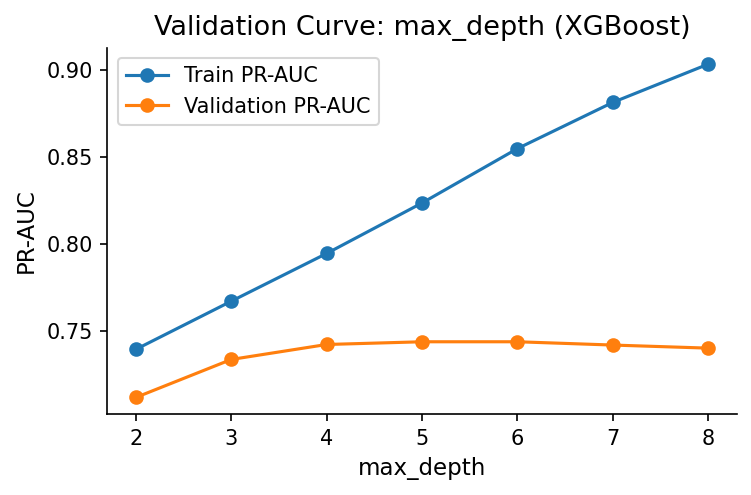

In [33]:
depth_values = [2, 3, 4, 5, 6, 7, 8]
train_scores_depth, val_scores_depth = [], []

for d in depth_values:
    tr, va = pr_auc_on_train_val({"max_depth": d})
    train_scores_depth.append(tr)
    val_scores_depth.append(va)

plot_validation_curve(
    depth_values,
    train_scores_depth,
    val_scores_depth,
    x_label="max_depth",
    title="Validation Curve: max_depth (XGBoost)",
    fig_name="fig06_2_validation_curve_max_depth",
)

### 6.2.2 Validation Curve: n_estimators

The validation curve for n_estimators indicates that validation PR-AUC improves as the number of boosting rounds increases, but stabilises beyond a moderate number of estimators.

  Saved: fig06_2_validation_curve_n_estimators


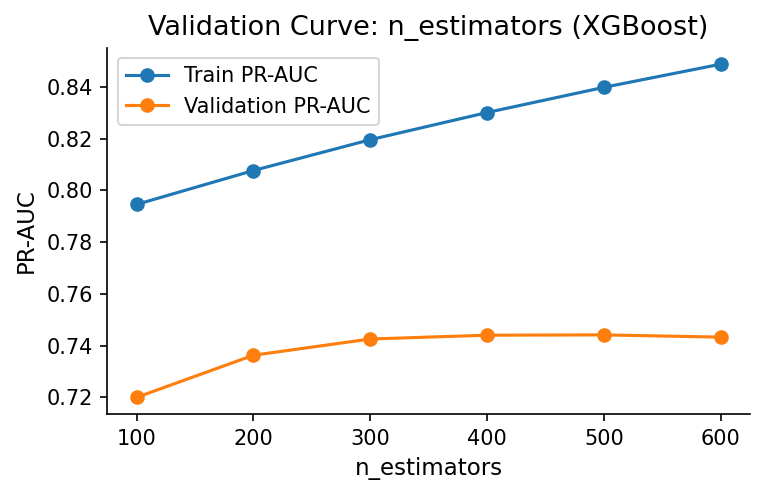

In [34]:
n_estimators_values = [100, 200, 300, 400, 500, 600]
train_scores_n, val_scores_n = [], []

for n in n_estimators_values:
    tr, va = pr_auc_on_train_val({"n_estimators": n})
    train_scores_n.append(tr)
    val_scores_n.append(va)

plot_validation_curve(
    n_estimators_values,
    train_scores_n,
    val_scores_n,
    x_label="n_estimators",
    title="Validation Curve: n_estimators (XGBoost)",
    fig_name="fig06_2_validation_curve_n_estimators",
)

### 6.2.3 Validation Curve: learning_rate

The validation curve for learning_rate shows increasing divergence 
between training and validation PR-AUC as the learning rate rises. 
Validation performance peaks in the [0.01, 0.1] range and begins 
to flatten beyond 0.1, suggesting that higher values risk overfitting. 
This evidence informed the upper bound of the Optuna search space, 
which was set to 0.2 (§6.1.2).

  Saved: fig06_2_validation_curve_learning_rate


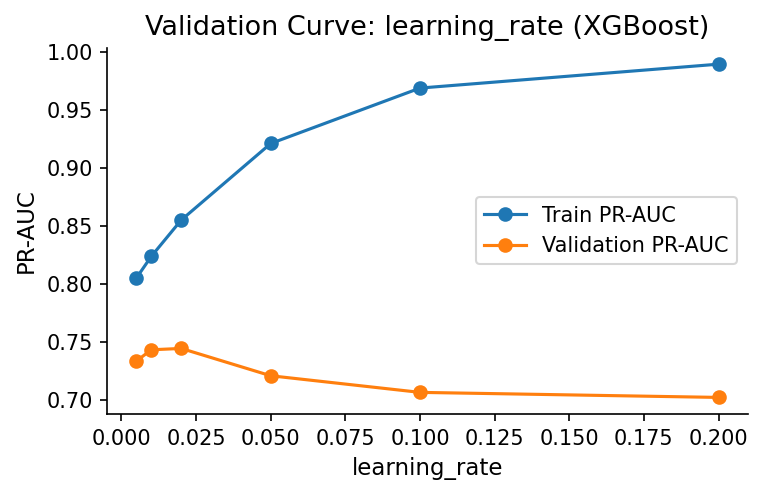

In [35]:
learning_rate_values = [0.005, 0.01, 0.02, 0.05, 0.1, 0.2]
train_scores_lr, val_scores_lr = [], []

for lr in learning_rate_values:
    tr, va = pr_auc_on_train_val({"learning_rate": lr})
    train_scores_lr.append(tr)
    val_scores_lr.append(va)

plot_validation_curve(
    learning_rate_values,
    train_scores_lr,
    val_scores_lr,
    x_label="learning_rate",
    title="Validation Curve: learning_rate (XGBoost)",
    fig_name="fig06_2_validation_curve_learning_rate",
)

### 6.2.4 Validation Curve Summary

Across all validation curves, training performance increases monotonically with model capacity, while validation PR-AUC stabilises within a narrow range.

This indicates that increasing model complexity beyond the selected ranges yields diminishing returns on validation performance.
Overall, the hyperparameter ranges defined in Section 6.1 provide a good balance between model expressiveness and generalisation, with no evidence of severe overfitting.

## 6.3 Threshold Optimisation

Unlike previous sections where a fixed threshold of 0.5 was used for fair model comparison, this section focuses on selecting an appropriate decision threshold for the refined XGBoost model.

All threshold-related decisions are based exclusively on validation set performance.
The test set remains untouched and is reserved for the final evaluation in Section 7.

### 6.3.1 Threshold Evaluation Strategy

While PR-AUC evaluates the model’s ability to rank positive cases above negative ones, a decision threshold is required to convert predicted probabilities into class-level purchase predictions.

Thresholds are evaluated by sweeping across a range of probability cut-offs and computing classification metrics on the validation set.
The primary metric of interest is the F1-score, as it captures the trade-off between precision and recall under class imbalance.

This analysis is not intended to aggressively maximise validation performance, but to identify a stable and interpretable operating point that reflects a reasonable balance between false positives and false negatives.

### 6.3.2 Threshold Sweep and Metric Evaluation

In [36]:
# ------------------------------------------------------------------
# 0) Prepare validation labels and predicted probabilities
# ------------------------------------------------------------------
y_val_int = np.asarray(y_val).astype(int)

best_params = BEST_PARAMS.copy()
best_params.update({
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "scale_pos_weight": SCALE_POS_WEIGHT,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
})

pipe_xgb_final = ImbPipeline(
    steps=[
        ("prep", preprocessor),
        ("clf", XGBClassifier(**best_params)),
    ]
)

pipe_xgb_final.fit(X_train, y_train_int)
y_val_proba = pipe_xgb_final.predict_proba(X_val)[:, 1]

# ------------------------------------------------------------------
# 1) Sweep thresholds and compute metrics
# ------------------------------------------------------------------
thresholds = np.linspace(0.05, 0.95, 19)

precision_scores = []
recall_scores = []
f1_scores = []

for t in thresholds:
    y_pred = (y_val_proba >= t).astype(int)
    precision_scores.append(
        precision_score(y_val_int, y_pred, zero_division=0)
    )
    recall_scores.append(
        recall_score(y_val_int, y_pred)
    )
    f1_scores.append(
        f1_score(y_val_int, y_pred)
    )

# ------------------------------------------------------------------
# 2) Select optimal threshold by F1-score
# ------------------------------------------------------------------
best_idx = int(np.argmax(f1_scores))
best_threshold = thresholds[best_idx]

print(f"Optimal threshold (by F1-score): {best_threshold:.2f}")
print(f"Precision: {precision_scores[best_idx]:.4f}")
print(f"Recall:    {recall_scores[best_idx]:.4f}")
print(f"F1-score:  {f1_scores[best_idx]:.4f}")

Optimal threshold (by F1-score): 0.65
Precision: 0.6518
Recall:    0.7133
F1-score:  0.6811


### 6.3.3 Selected Threshold and Interpretation

The validation-based threshold sweep identifies an optimal decision threshold of 0.65, which maximises the F1-score on the validation set.

At this operating point, the model achieves a balanced trade-off between precision and recall, representing a reasonable compromise between false positive and false negative errors under class imbalance.

This threshold is fixed for the final evaluation on the held-out test set in Section 7, with no further threshold tuning performed beyond this stage.

# 7. Final Evaluation on Test Set

This section reports the final performance of the refined XGBoost model on the held-out test set.
All modelling decisions, including preprocessing, hyperparameter tuning, and decision threshold selection, were finalised using the training and validation sets only.

The test set has remained completely untouched until this stage and is used solely to estimate the model’s generalisation performance.

## 7.1 Final Test Performance

The refined XGBoost model is trained on the full training data using the hyperparameters selected in Section 6.1 and the decision threshold determined in Section 6.3.  
Performance is evaluated on the held-out test set using imbalance-aware metrics.

In [37]:
# ------------------------------------------------------------
# Prepare labels
# ------------------------------------------------------------
y_train_int = np.asarray(y_train).astype(int)
y_test_int  = np.asarray(y_test).astype(int)

# ------------------------------------------------------------
# Final model using tuned parameters and selected threshold
# ------------------------------------------------------------
final_params = BEST_PARAMS.copy()
final_params.update({
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "scale_pos_weight": SCALE_POS_WEIGHT,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
})

pipe_xgb_final = ImbPipeline(
    steps=[
        ("prep", preprocessor),
        ("clf", XGBClassifier(**final_params)),
    ]
)

pipe_xgb_final.fit(X_train, y_train_int)

y_test_proba = pipe_xgb_final.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= best_threshold).astype(int)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
test_pr_auc  = average_precision_score(y_test_int, y_test_proba)
test_roc_auc = roc_auc_score(y_test_int, y_test_proba)
test_f1      = f1_score(y_test_int, y_test_pred)
test_brier   = brier_score_loss(y_test_int, y_test_proba)

print(f"PR-AUC (Test):  {test_pr_auc:.4f}")
print(f"ROC-AUC (Test): {test_roc_auc:.4f}")
print(f"F1-score:      {test_f1:.4f}")
print(f"Brier score:   {test_brier:.4f}")

PR-AUC (Test):  0.7568
ROC-AUC (Test): 0.9363
F1-score:      0.6795
Brier score:   0.0984


The refined XGBoost model shows strong performance on the held-out test set, indicating that the ranking and classification behaviour observed during validation generalises well to unseen data.

## 7.2 ROC & Precision–Recall Curves

ROC and Precision–Recall curves are plotted on the test set to visualise ranking quality and class-separation behaviour.  
Given the strong class imbalance, the Precision–Recall curve is particularly informative.

  Saved: fig07_2_pr_curve_test


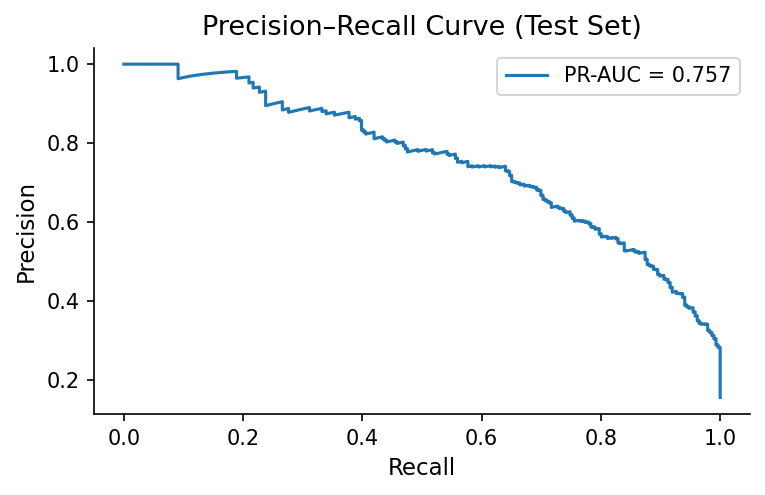

  Saved: fig07_2_roc_curve_test


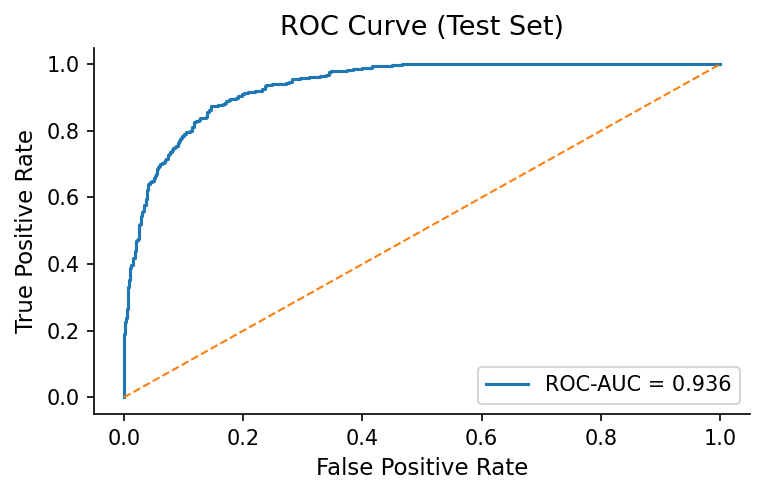

In [38]:
# Prepare test labels
y_test_int = np.asarray(y_test).astype(int)

# Predicted probabilities from the refined XGBoost model
y_test_proba = pipe_xgb_final.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------------
# Precision–Recall Curve
# ------------------------------------------------------------------
precision, recall, _ = precision_recall_curve(y_test_int, y_test_proba)
pr_auc = average_precision_score(y_test_int, y_test_proba)

plt.figure(figsize=(5.2, 3.4))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Test Set)")
plt.legend()
plt.tight_layout()
save_fig("fig07_2_pr_curve_test")
plt.show()

# ------------------------------------------------------------------
# ROC Curve
# ------------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_test_int, y_test_proba)
roc_auc = roc_auc_score(y_test_int, y_test_proba)

plt.figure(figsize=(5.2, 3.4))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend()
plt.tight_layout()
save_fig("fig07_2_roc_curve_test")
plt.show()

The Precision–Recall curve on the test set shows that the model maintains strong ranking performance under severe class imbalance. High precision is preserved across a wide range of recall values. This means that positive purchase sessions are consistently ranked ahead of negative ones.

The ROC curve also confirms strong class-separation ability. It shows a high true positive rate at relatively low false positive rates. These results suggest that the refined XGBoost model generalises well to unseen data and retains stable discrimination performance beyond the validation set.

## 7.3 Confusion Matrix at Selected Threshold

To examine class-level prediction behaviour, a confusion matrix is computed on the test set using the decision threshold selected in Section 6.3.

This analysis provides an intuitive view of how predicted purchase decisions are distributed across true positives, false positives, true negatives, and false negatives, complementing the aggregate metrics reported earlier.

All results in this section are based on the held-out test set and reflect the model’s final operating point.

  Saved: fig07_3_confusion_matrix_test


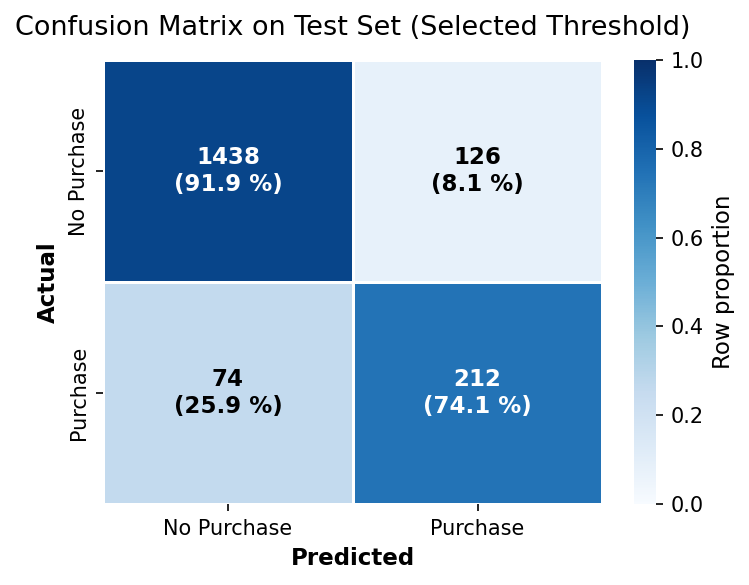

In [39]:
# Ensure labels are integer-encoded
y_test_int = np.asarray(y_test).astype(int)

# Predict probabilities on the test set using the final trained model
y_test_proba = pipe_xgb_final.predict_proba(X_test)[:, 1]

# Apply the selected decision threshold from Section 6.3
y_test_pred = (y_test_proba >= best_threshold).astype(int)

# Plot confusion matrix
plot_confusion_matrix_custom(
    y_true=y_test_int,
    y_pred=y_test_pred,
    title="Confusion Matrix on Test Set (Selected Threshold)",
    filename="fig07_3_confusion_matrix_test",
)

To examine class-level prediction behaviour, a confusion matrix is computed 
on the test set using the decision threshold selected in Section 6.3.

The confusion matrix provides an intuitive view of how predicted purchase 
decisions are distributed across true positives, false positives, true 
negatives, and false negatives, complementing the aggregate performance 
metrics reported earlier.

At threshold = 0.65, the model correctly identifies 212 of 286 purchase 
sessions (recall = 74.1%) while generating 126 false positives from 1,564 
non-purchasing sessions (false positive rate = 8.1%), yielding precision = 
62.7% and F1 = 0.680. The higher recall relative to precision reflects the 
cost asymmetry in the coupon targeting context: missing a likely buyer 
forfeits revenue, while an unnecessary coupon has a bounded cost.

All results in this section are based on the held-out test set and reflect 
the model's final deployment configuration.

## 7.4 Probability Calibration for Decision Readiness

While ranking metrics such as PR-AUC and ROC-AUC evaluate how well the model orders sessions by purchase likelihood, calibrated probabilities are needed when predicted scores are used as confidence estimates or for downstream decision-making.

This section examines the calibration behaviour of the refined XGBoost model on the held-out test set.
All analyses are conducted using the final model configuration and decision threshold, with no further tuning.

### 7.4.1 Calibration Curve (Test Set)

  Saved: fig07_4_calibration_curve


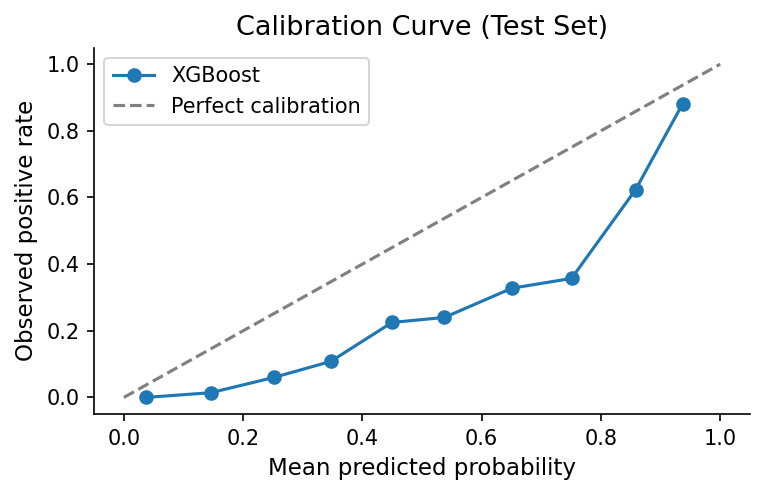

In [40]:
# Ensure test labels are integer-encoded
y_test_int = np.asarray(y_test).astype(int)

# Predicted probabilities from the final trained model
y_test_proba = pipe_xgb_final.predict_proba(X_test)[:, 1]

# Compute calibration curve
prob_true, prob_pred = calibration_curve(
    y_test_int,
    y_test_proba,
    n_bins=10,
    strategy="uniform"
)

# Plot calibration curve
plt.figure(figsize=(5.2, 3.4))
plt.plot(prob_pred, prob_true, marker="o", label="XGBoost")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive rate")
plt.title("Calibration Curve (Test Set)")
plt.legend()
plt.tight_layout()
save_fig("fig07_4_calibration_curve")
plt.show()

The calibration curve shows that the refined XGBoost model produces reasonably aligned probability estimates on the test set, particularly at higher confidence levels. While some deviation from perfect calibration is observed in the mid-probability range, the model remains reliable when assigning high purchase likelihoods.

This indicates that the predicted probabilities are suitable for downstream decision-making, with minor calibration error that does not undermine overall model reliability.

### 7.4.2 Brier Score Assessment

The Brier score is reported as a complementary quantitative measure of probability calibration.
Lower values indicate better agreement between predicted probabilities and observed outcomes.

In [41]:
brier = brier_score_loss(y_test_int, y_test_proba)
print(f"Brier Score (Test Set): {brier:.6f}")

Brier Score (Test Set): 0.098396


## 7.5 Model Explainability: SHAP Analysis

This section examines the interpretability of the refined XGBoost model using SHAP (SHapley Additive exPlanations).
SHAP values provide a unified framework for explaining individual predictions and global feature importance by quantifying each feature’s contribution to the model output.

All analyses in this section are conducted on the held-out test set using the final trained model configuration.

### 7.5.1 SHAP Global Feature Importance

The global feature importance plot summarises the average magnitude of each feature’s contribution to the model predictions.
Features are ranked by their mean absolute SHAP values, indicating their overall influence on purchase likelihood.

  Saved: fig07_5_shap_summary_bar


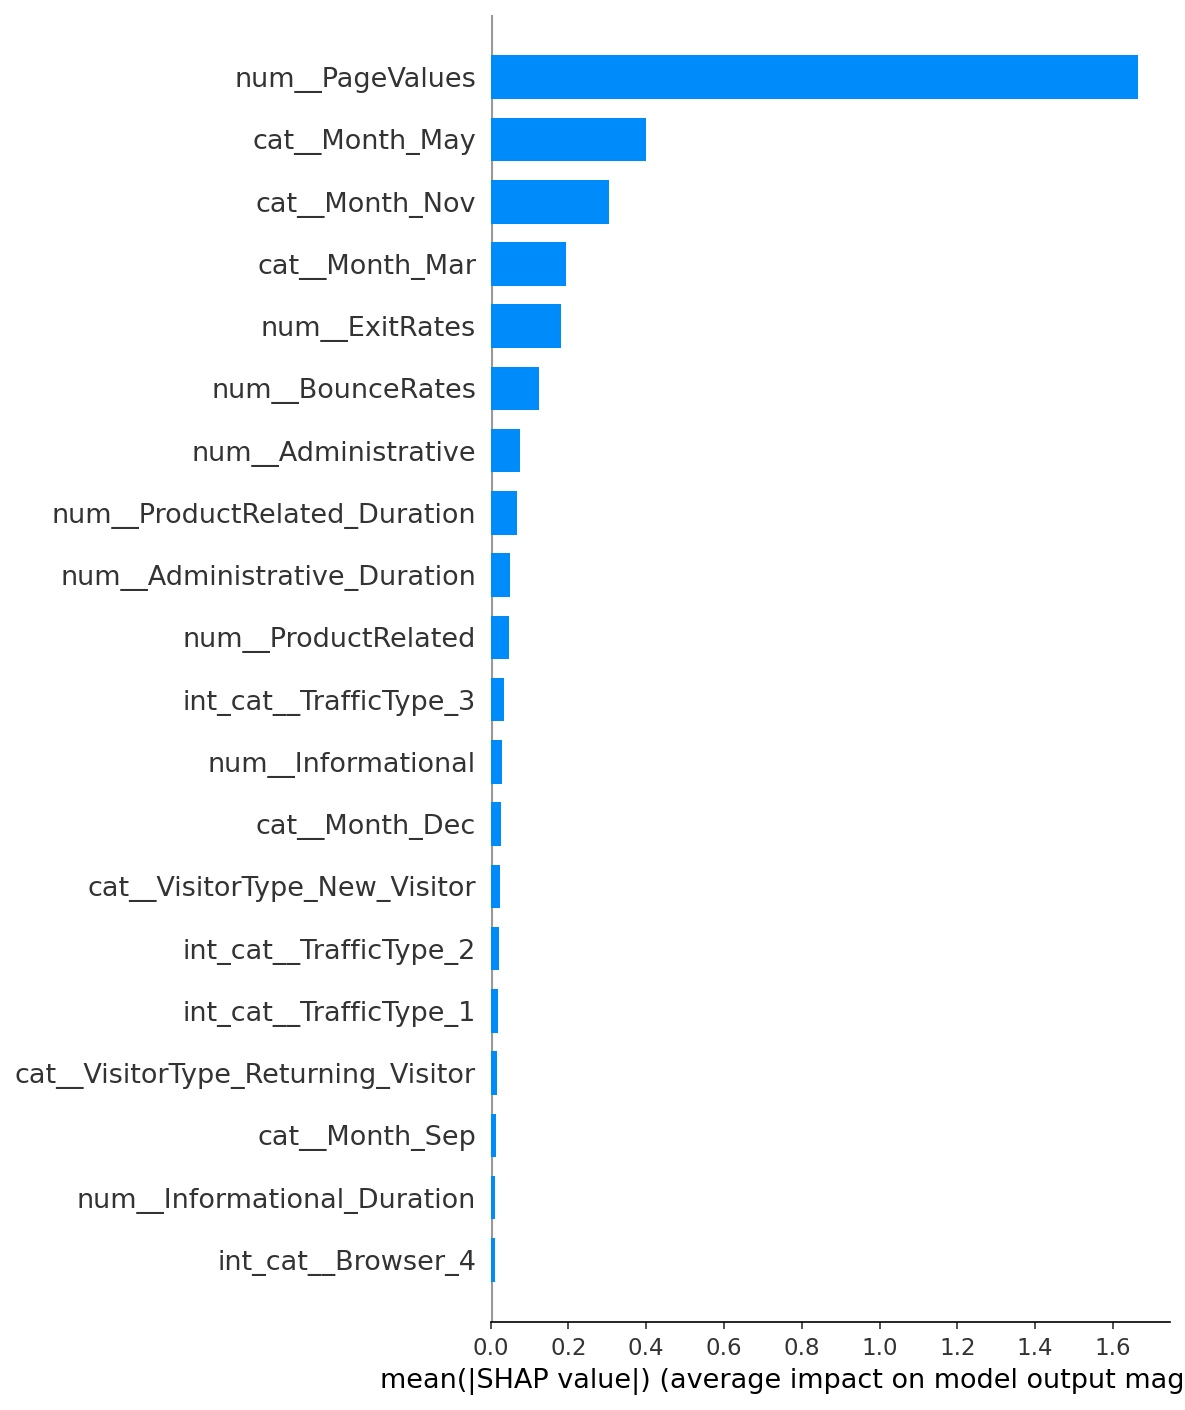

In [42]:
# Extract fitted preprocessor and model
prep = pipe_xgb_final.named_steps["prep"]
xgb  = pipe_xgb_final.named_steps["clf"]

# Transform test data
X_test_trans = prep.transform(X_test)

# Feature names
try:
    feature_names = prep.get_feature_names_out()
except Exception:
    feature_names = np.array([f"f{i}" for i in range(X_test_trans.shape[1])])

# Ensure dense matrix for SHAP
if hasattr(X_test_trans, "toarray"):
    X_test_dense = X_test_trans.toarray()
else:
    X_test_dense = np.asarray(X_test_trans)

# Subsample for efficiency
rng = np.random.RandomState(RANDOM_STATE)
n_sample = min(2000, X_test_dense.shape[0])
idx = rng.choice(X_test_dense.shape[0], size=n_sample, replace=False)

X_shap = X_test_dense[idx]

# Compute SHAP values
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_shap)

# Plot: SHAP bar summary
plt.figure(figsize=(5.2, 3.4))
shap.summary_plot(
    shap_values,
    features=X_shap,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.tight_layout()
save_fig("fig07_5_shap_summary_bar")
plt.show()

The plot shows that PageValues is the most influential feature in the model,
exhibiting substantially larger SHAP contributions than all other features.
Several temporal features (month indicators) and engagement-related metrics
also contribute to the predictions, but with markedly smaller effects.

### 7.5.2 SHAP Summary Plot

The SHAP summary (beeswarm) plot shows both the importance and direction of each feature’s effect.
Each point represents an observation, with colour indicating the feature value and position reflecting its impact on the predicted purchase probability.

  Saved: fig07_5_shap_summary_beeswarm


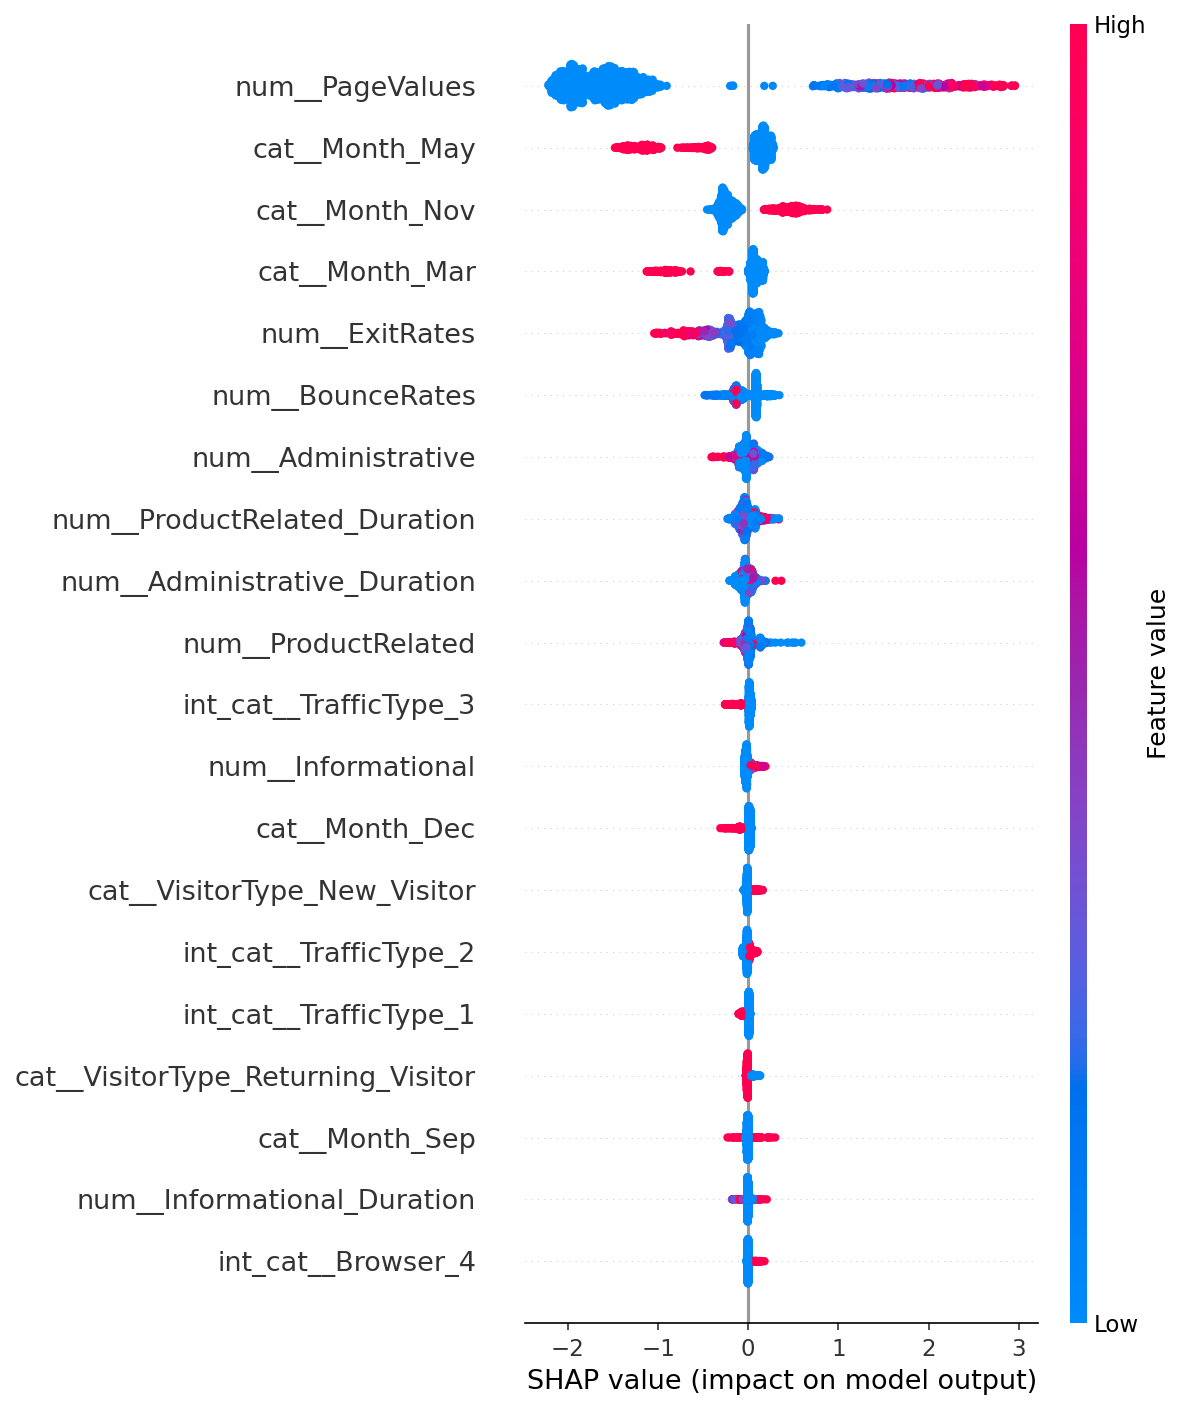

In [43]:
plt.figure(figsize=(5.2, 3.4))
shap.summary_plot(
    shap_values,
    features=X_shap,
    feature_names=feature_names,
    show=False
)
plt.tight_layout()
save_fig("fig07_5_shap_summary_beeswarm")
plt.show()

The plot shows both the direction and magnitude of each feature’s effect on purchase likelihood. Higher PageValues consistently increase the predicted probability of purchase, while higher ExitRates and BounceRates tend to reduce it. Temporal features and traffic-related indicators have more mixed effects, with smaller and less consistent contributions across sessions.

### 7.5.3 SHAP Dependence Plot

A SHAP dependence plot is used to examine how the most influential feature affects predictions.
The plot shows the relationship between the feature value and its SHAP contribution and highlights possible non-linear effects and interactions.

  Saved: fig07_5_shap_dependence_top_feature


<Figure size 780x510 with 0 Axes>

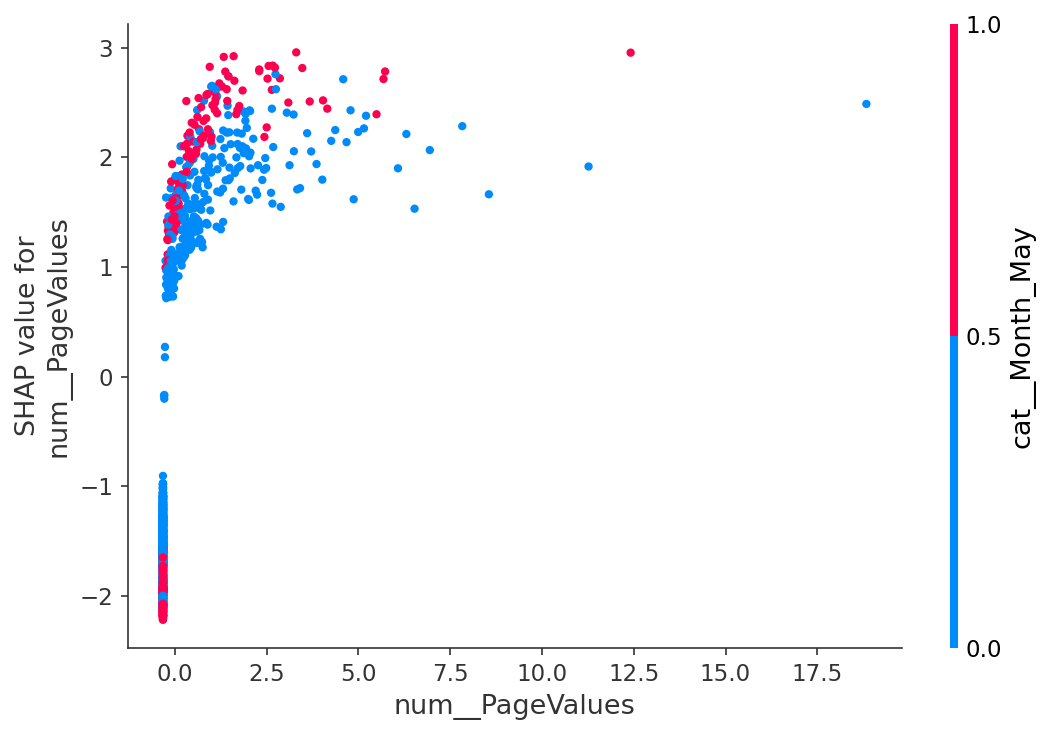

Top SHAP feature: num__PageValues


In [44]:
# Identify top feature by mean absolute SHAP value
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_idx = int(np.argmax(mean_abs_shap))
top_feature = feature_names[top_idx]

plt.figure(figsize=(5.2, 3.4))
shap.dependence_plot(
    top_idx,
    shap_values,
    X_shap,
    feature_names=feature_names,
    show=False
)
plt.tight_layout()
save_fig("fig07_5_shap_dependence_top_feature")
plt.show()

print(f"Top SHAP feature: {top_feature}")

The dependence plot shows a strong positive relationship between PageValues and purchase likelihood.
When PageValues increase, the SHAP contribution increases sharply and then levels off, which shows diminishing returns at higher values.
The colour gradient also suggests a possible interaction with month, especially May, within the model’s learned decision structure.

## 7.6 Failure Mode Analysis and Risk Interpretation

The confusion matrix shows that most errors are false positives, where sessions with moderate engagement are classified as purchases.
This means the model focuses more on recall than precision at the selected threshold.

False negatives are fewer and mainly occur in low-engagement sessions.
This matches the model’s ranking-based optimisation objective.

Overall, the error patterns are clear and consistent with the trade-offs created by threshold selection under class imbalance.

### 7.6.1 Error counts and numeric summary

In [45]:
# ------------------------------------------------------------
# 0) Use the selected threshold from Section 6.3 (robust fallback)
# ------------------------------------------------------------
if "best_threshold" in globals():
    THRESHOLD = float(best_threshold)
elif "optimal_threshold" in globals():
    THRESHOLD = float(optimal_threshold)
else:
    raise NameError("Selected threshold not found. Please run Section 6.3 first (best_threshold / optimal_threshold).")

# ------------------------------------------------------------
# 1) Ensure the final test probabilities are available
#    (pipe_xgb_final and y_test_proba were created in Section 7.1/7.2)
# ------------------------------------------------------------
if "pipe_xgb_final" not in globals():
    raise NameError("pipe_xgb_final not found. Please run Section 7.1 first to fit the final model.")
if "y_test_proba" not in globals():
    y_test_proba = pipe_xgb_final.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# 2) Prepare labels and predictions on the test set
# ------------------------------------------------------------
y_test_int = np.asarray(y_test).astype(int)
y_test_pred = (y_test_proba >= THRESHOLD).astype(int)

# ------------------------------------------------------------
# 3) Error counts (FP / FN) at selected threshold
# ------------------------------------------------------------
tn, fp, fn, tp = confusion_matrix(y_test_int, y_test_pred).ravel()

print(f"Decision threshold used: {THRESHOLD:.3f}")
print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"True Negatives (TN): {tn}")
print(f"False Negatives (FN): {fn}\n")

# ------------------------------------------------------------
# 3b) Precision / Recall / F1 at selected threshold (auditability)
# ------------------------------------------------------------
from sklearn.metrics import precision_score, recall_score, f1_score

prec = precision_score(y_test_int, y_test_pred, zero_division=0)
rec  = recall_score(y_test_int, y_test_pred, zero_division=0)
f1   = f1_score(y_test_int, y_test_pred, zero_division=0)

print(f"Precision (Test Set @ {THRESHOLD:.3f}): {prec:.4f}  ({prec*100:.1f}%)")
print(f"Recall    (Test Set @ {THRESHOLD:.3f}): {rec:.4f}  ({rec*100:.1f}%)")
print(f"F1        (Test Set @ {THRESHOLD:.3f}): {f1:.4f}\n")


# ------------------------------------------------------------
# 4) Numeric summary: compare All / FP / FN on key numeric features
# ------------------------------------------------------------
test_df = X_test.copy()
test_df = test_df.assign(
    y_true=y_test_int,
    y_pred=y_test_pred,
    y_proba=y_test_proba,
)

test_df["group"] = "All test"
test_df.loc[(test_df["y_true"] == 0) & (test_df["y_pred"] == 1), "group"] = "FP (true=0, pred=1)"
test_df.loc[(test_df["y_true"] == 1) & (test_df["y_pred"] == 0), "group"] = "FN (true=1, pred=0)"

key_numeric = [
    "PageValues",
    "BounceRates",
    "ExitRates",
    "ProductRelated",
    "ProductRelated_Duration",
]

available_numeric = [c for c in key_numeric if c in test_df.columns]

summary_numeric = (
    test_df.groupby("group")[available_numeric]
    .agg(["mean", "median"])
    .reset_index()
)

display(summary_numeric)

Decision threshold used: 0.650
True Positives (TP): 212
False Positives (FP): 126
True Negatives (TN): 1438
False Negatives (FN): 74

Precision (Test Set @ 0.650): 0.6272  (62.7%)
Recall    (Test Set @ 0.650): 0.7413  (74.1%)
F1        (Test Set @ 0.650): 0.6795



group PageValues            BounceRates           ExitRates  \
                             mean     median        mean    median      mean   
0             All test   4.793090   0.000000    0.022855  0.003022  0.044133   
1  FN (true=1, pred=0)   1.208609   0.000000    0.013016  0.005942  0.031838   
2  FP (true=0, pred=1)  21.424018  14.799987    0.006883  0.004168  0.022791   

            ProductRelated        ProductRelated_Duration               
     median           mean median                    mean       median  
0  0.026432      29.607273   17.0             1115.906353   517.470833  
1  0.025552      60.445946   27.0             2113.976760  1083.159722  
2  0.019925      55.896825   37.5             2126.767452  1415.445387

The numeric summary shows that false positives are more common than false negatives at the selected threshold (FP=126 vs FN=74).
Compared with the overall test set, false positives tend to exhibit stronger commercial intent, notably higher PageValues and ProductRelated activity alongside lower BounceRates and ExitRates.
False negatives show a more mixed pattern: despite relatively high ProductRelated activity, they have near-zero PageValues, suggesting engagement that does not translate into immediate value.
This aligns with the cost framing: the chosen operating point accepts some coupon waste (FP) to reduce missed conversions (FN), and the threshold can be shifted if business priorities change.

### 7.6.2 Feature-Level Comparison (FP vs FN)

This section compares key feature distributions between false positive and false negative predictions on the test set.
The aim is to identify which behavioural signals differ most clearly between these two error types.

To keep the analysis readable, only the most informative engagement-related features are visualised.

Decision threshold used: 0.650
False Positives (FP): 126
False Negatives (FN): 74

  Saved: fig07_6_fp_fn_feature_distributions_grid


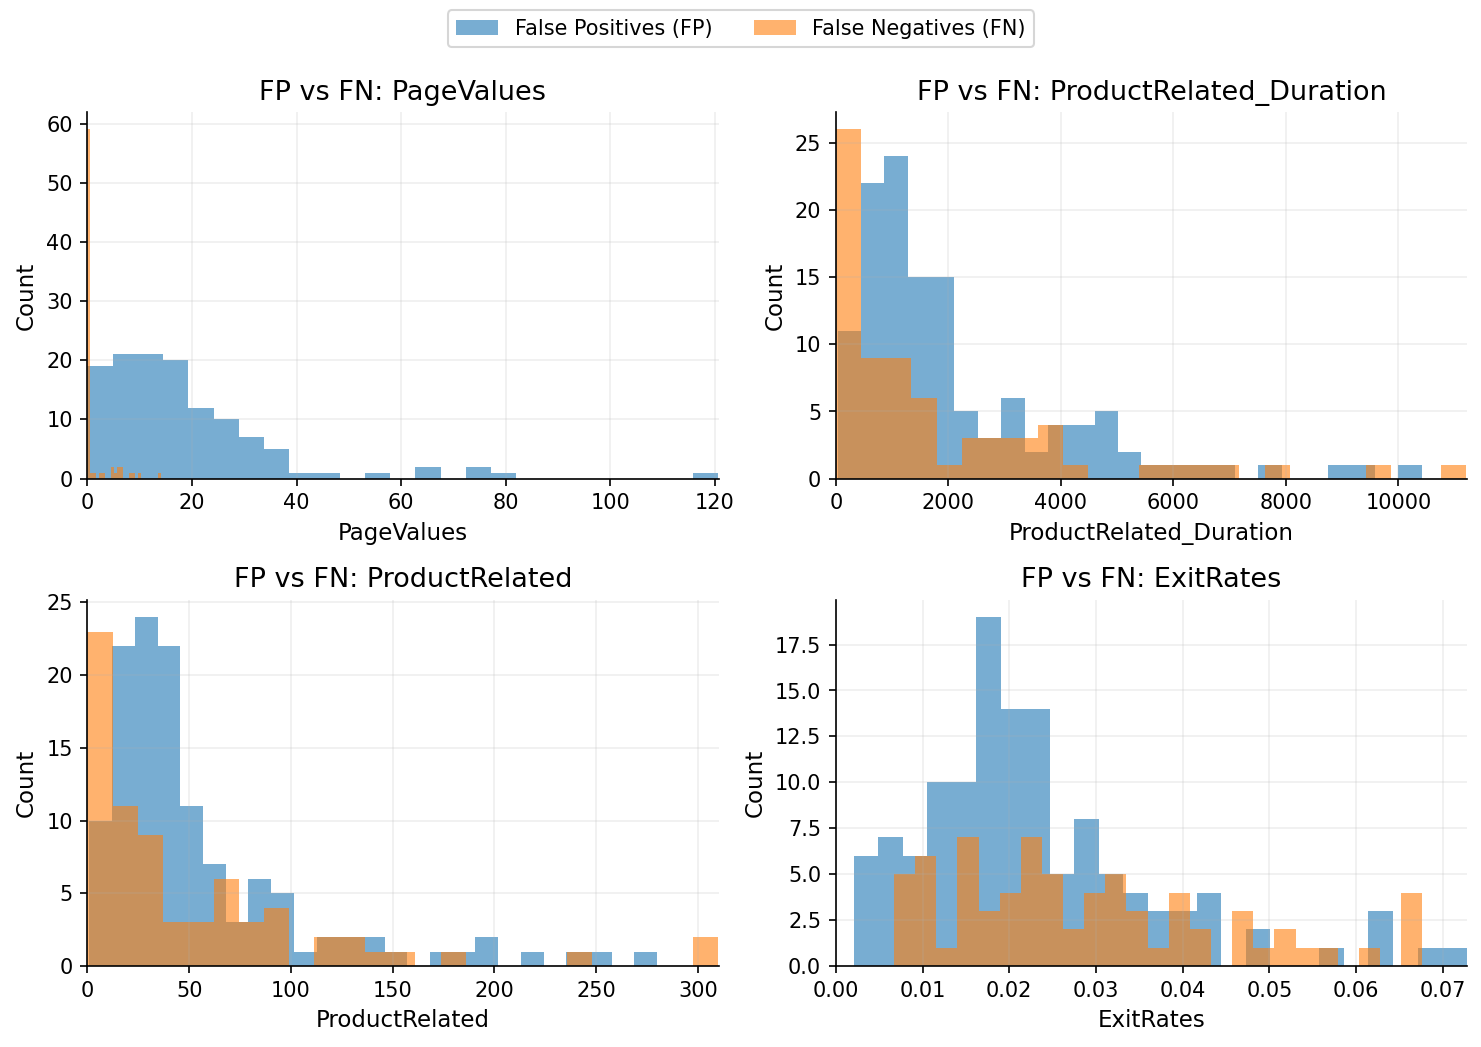

,Feature,FP_mean,FN_mean,FP_median,FN_median
0,PageValues,21.424018,1.208609,14.799987,0.000000
1,ProductRelated_Duration,2126.767452,2113.976760,1415.445387,1083.159722
2,ProductRelated,55.896825,60.445946,37.500000,27.000000
3,ExitRates,0.022791,0.031838,0.019925,0.025552


In [46]:
# ------------------------------------------------------------
# 1) Load selected threshold and final model outputs
# ------------------------------------------------------------
if "best_threshold" in globals():
    THRESHOLD = float(best_threshold)
elif "optimal_threshold" in globals():
    THRESHOLD = float(optimal_threshold)
else:
    raise NameError("Selected threshold not found. Run Section 6.3 first (best_threshold / optimal_threshold).")

if "pipe_xgb_final" not in globals():
    raise NameError("pipe_xgb_final not found. Run Section 7.1 first.")

y_test_int = np.asarray(y_test).astype(int)
y_test_proba = pipe_xgb_final.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= THRESHOLD).astype(int)

df_err = X_test.copy()
df_err = df_err.assign(
    y_true=y_test_int,
    y_pred=y_test_pred,
    y_proba=y_test_proba
)

fp_mask = (df_err["y_true"] == 0) & (df_err["y_pred"] == 1)
fn_mask = (df_err["y_true"] == 1) & (df_err["y_pred"] == 0)

print(f"Decision threshold used: {THRESHOLD:.3f}")
print(f"False Positives (FP): {fp_mask.sum()}")
print(f"False Negatives (FN): {fn_mask.sum()}\n")

# ------------------------------------------------------------
# 2) Plot FP vs FN distributions (bounded to 99th percentile)
# ------------------------------------------------------------
def plot_fp_fn_hist(ax, df, feature, bins=25):
    fp = df.loc[fp_mask, feature].dropna().values
    fn = df.loc[fn_mask, feature].dropna().values

    if (len(fp) + len(fn)) == 0:
        ax.set_title(f"FP vs FN: {feature}")
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.axis("off")
        return

    all_vals = np.concatenate([fp, fn])
    x_max = np.percentile(all_vals, 99)

    if np.isfinite(x_max) and x_max > 0:
        fp_plot = fp[fp <= x_max]
        fn_plot = fn[fn <= x_max]
        ax.set_xlim(0, x_max)
    else:
        fp_plot, fn_plot = fp, fn

    ax.hist(fp_plot, bins=bins, alpha=0.6, label="False Positives (FP)")
    ax.hist(fn_plot, bins=bins, alpha=0.6, label="False Negatives (FN)")
    ax.set_title(f"FP vs FN: {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.2)

features_to_compare = ["PageValues", "ProductRelated_Duration", "ProductRelated", "ExitRates"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.ravel()

for ax, feat in zip(axes, features_to_compare):
    if feat not in df_err.columns:
        ax.axis("off")
        ax.set_title(f"Missing: {feat}")
        continue
    plot_fp_fn_hist(ax, df_err, feat, bins=25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.95])
save_fig("fig07_6_fp_fn_feature_distributions_grid")
plt.show()

# ------------------------------------------------------------
# 3) Numeric summary table (FP vs FN)
# ------------------------------------------------------------
summary_rows = []
for feat in features_to_compare:
    if feat not in df_err.columns:
        continue
    fp_vals = df_err.loc[fp_mask, feat].dropna()
    fn_vals = df_err.loc[fn_mask, feat].dropna()

    summary_rows.append({
        "Feature": feat,
        "FP_mean": fp_vals.mean(),
        "FN_mean": fn_vals.mean(),
        "FP_median": fp_vals.median(),
        "FN_median": fn_vals.median(),
    })

summary_fp_fn = pd.DataFrame(summary_rows)
display(summary_fp_fn)

False positives show stronger engagement signals, such as higher PageValues and longer product-related durations, which push predicted probabilities above the selected threshold despite no purchase.

False negatives exhibit weaker engagement across the same features, keeping predicted probabilities below the threshold even when a purchase occurs.

These feature-level differences explain the error patterns observed in Section 7.6.1 and reflect the trade-offs introduced by threshold-based decisions under class imbalance.

### 7.6.3 Categorical Pattern Analysis

This section examines categorical patterns associated with false positive and false negative predictions on the test set.
The analysis focuses on high-level behavioural categories that plausibly influence purchase intent, rather than exhaustively analysing all categorical variables.

Specifically, error patterns are analysed across VisitorType and Month, as these dimensions reflect differences in user intent and seasonal purchasing behaviour.
Only the most informative categorical features are presented to maintain clarity and relevance.

  Saved: fig07_6_visitor_type_error_share


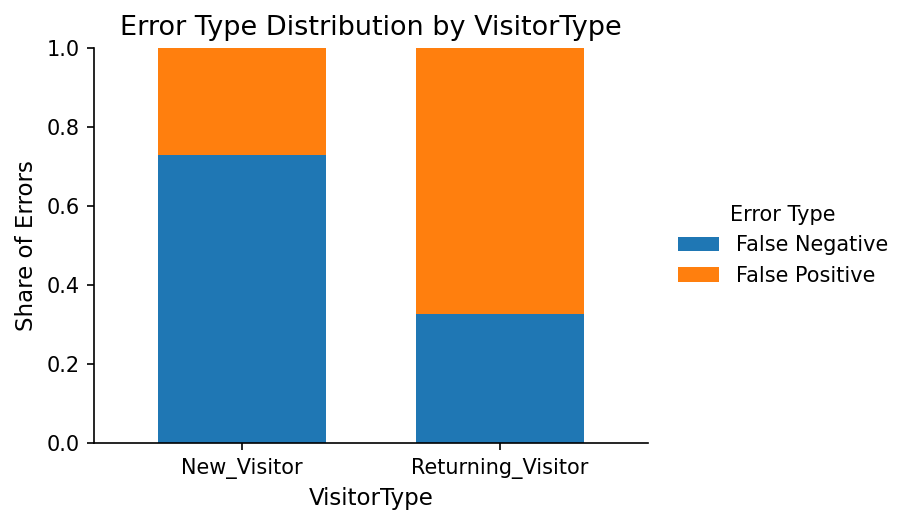

  Saved: fig07_6_month_error_frequency


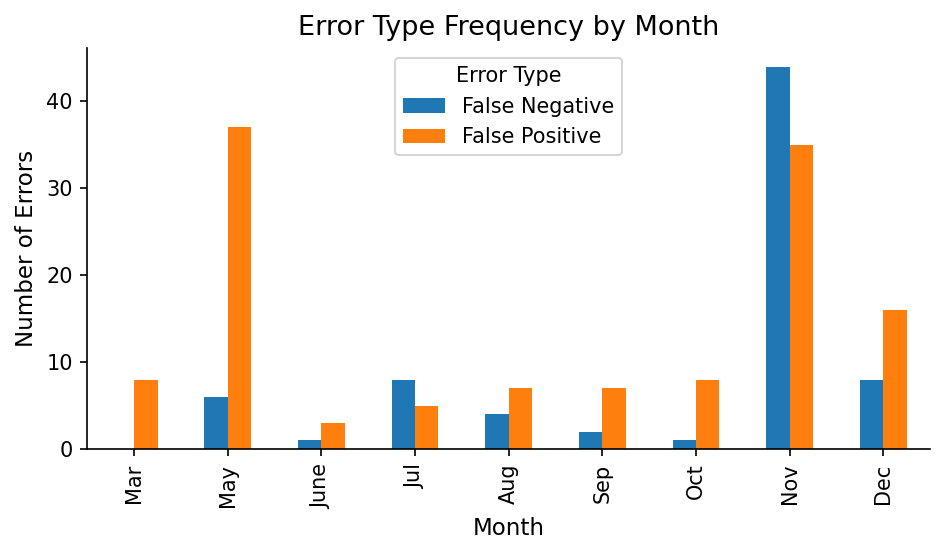

In [47]:
# Prepare error dataframe
df_err = X_test.copy()
df_err["y_true"] = y_test_int
df_err["y_pred"] = y_test_pred

df_err = df_err.loc[df_err["y_true"] != df_err["y_pred"]].copy()
df_err["error_type"] = df_err.apply(
    lambda r: "False Positive" if r["y_pred"] == 1 else "False Negative",
    axis=1
)

# ------------------------------------------------------------
# 1) VisitorType × Error Type (100% stacked bar)
# ------------------------------------------------------------
visitor_dist = (
    df_err.groupby(["VisitorType", "error_type"])
    .size()
    .reset_index(name="count")
)

visitor_pct = visitor_dist.copy()
visitor_pct["share"] = (
    visitor_pct.groupby("VisitorType")["count"]
    .transform(lambda x: x / x.sum())
)

pivot_visitor = visitor_pct.pivot(
    index="VisitorType",
    columns="error_type",
    values="share"
).fillna(0)

fig, ax = plt.subplots(figsize=(6.2, 3.6))

pivot_visitor.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.65
)

ax.set_title("Error Type Distribution by VisitorType")
ax.set_ylabel("Share of Errors")
ax.set_xlabel("VisitorType")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)

ax.legend(
    title="Error Type",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

fig.tight_layout()
save_fig("fig07_6_visitor_type_error_share")
plt.show()

# ------------------------------------------------------------
# 2) Month × Error Type (grouped bar)
# ------------------------------------------------------------
# Enforce natural month order
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
df_err["Month"] = pd.Categorical(df_err["Month"], categories=month_order, ordered=True)

month_dist = (
    df_err.groupby(["Month", "error_type"])
    .size()
    .reset_index(name="count")
)

pivot_month = month_dist.pivot(
    index="Month",
    columns="error_type",
    values="count"
).fillna(0)

pivot_month.plot(
    kind="bar",
    figsize=(6.4, 3.8)
)

plt.ylabel("Number of Errors")
plt.title("Error Type Frequency by Month")
plt.legend(title="Error Type")
plt.tight_layout()
save_fig("fig07_6_month_error_frequency")
plt.show()

False negatives occur more often for new visitors. This shows that limited behavioural signals make purchase intent harder to detect.

False positives are more common for returning visitors. This suggests that repeated visits are often interpreted as purchase intent even when no purchase occurs.

Error patterns also vary by month. False negatives are more common in November. This fits seasonal purchasing behaviour, where purchases can occur with weaker engagement signals.

# 8. Model Card

## 8.1 Intended Use & Out-of-Scope Use

The model is intended to support session-level decision-making on an e-commerce platform by estimating the likelihood that an active session results in a purchase.
It is designed to support actions such as targeted coupon allocation, prioritised user engagement, or traffic-level analysis.
In these cases, predicted probabilities are used as decision support, not as fixed or deterministic predictions.

The model is not intended to be used for individual-level profiling, long-term customer value estimation, or any form of automated decision-making with legal or financial consequences.
It should also not be interpreted as a measure of user intent beyond the observed session, as predictions are based solely on behavioural signals captured within a single visit.

## 8.2 Data Provenance & Constraints

The model is trained on a publicly available e-commerce session dataset containing anonymised behavioural data collected at the session level.
The dataset includes features such as page interactions, time spent on product-related pages, traffic source, visitor type, and temporal indicators.

All features are derived from a single browsing session and do not include personally identifiable information.
As a result, the model captures short-term behavioural patterns rather than long-term user preferences or customer histories.

Several constraints follow from this data design.
First, purchase behaviour is observed only at the session level, so repeat visits by the same user are treated as independent observations.
Second, the dataset reflects historical browsing patterns from a specific platform and time period, which may limit generalisation to other domains, seasons, or user populations.

These constraints mean that model predictions should be interpreted as contextual estimates based on observed session behaviour, not as stable indicators of individual customer intent.

## 8.3 Performance Summary & Caveats

The refined XGBoost model demonstrates strong ranking performance on the held-out test set, with stable PR-AUC and ROC-AUC scores indicating effective separation between purchasing and non-purchasing sessions.
Threshold-based evaluation further shows a reasonable balance between identifying purchase sessions and limiting unnecessary false positives.

Calibration analysis suggests that predicted probabilities are generally reliable at higher confidence levels, making the model suitable for downstream decision support where relative likelihood and prioritisation are required.
However, probability estimates show mild deviation in the mid-range, which should be considered when interpreting scores close to the decision threshold.

Several caveats apply to these results.
Model performance is evaluated at the session level and reflects short-term behavioural signals only.
Errors are not random but are influenced by visitor type and seasonal context, with higher false negatives among new visitors and increased error concentration during peak months such as November.

As a result, performance metrics should be interpreted as indicators of decision support quality rather than guarantees of individual purchase outcomes.
The model is best used in conjunction with business rules or monitoring mechanisms, especially in scenarios where user behaviour differs from historical patterns.

## 8.4 Limitations and Risks

Despite strong overall performance, the model has several limitations that should be considered when interpreting its predictions.

The model relies only on behavioural signals observed within a single session. For this reason, purchase intent can be underestimated for new visitors or sessions with low engagement. In contrast, repeated browsing behaviour is often interpreted as purchase intent for returning visitors, which can lead to false positive predictions.

Model performance also varies across time. Error rates differ by month, with higher error concentration during peak periods such as November. During these periods, purchases may occur even when engagement signals are weak. This means that model behaviour can change when seasonal patterns shift.

Predictions are probabilistic and should not be treated as definite indicators of user intent.
Using a fixed decision threshold introduces a trade-off between false positives and false negatives.
This trade-off is not a modelling decision, but a deployment choice that should be aligned with business priorities.

Taken together, these limitations show that the model is best used for decision support rather than fully automated actions. In practice, ongoing monitoring and periodic recalibration would be needed to maintain reliable performance.

# 9. Reflection on Agent Use & Verification

This section documents how AI agent tooling was used across the modelling workflow and, more importantly, how its outputs were verified, corrected, or rejected through human judgement. The focus is not on demonstrating agent usage itself, but on evidencing disciplined supervision, methodological reasoning, and accountability for all analytical decisions.

## 9.1 Summary of Agent Contributions

An AI coding assistant(Codex) was used as a supervised junior collaborator. Its role was limited to drafting structural code scaffolds and repetitive boilerplate. All decisions with statistical, methodological, or business implications were independently reviewed and approved by the analyst.

| Workflow Stage | Agent Output | Human Action |
|:---|:---|:---|
| **§0.3 Helper Functions** | Drafted `evaluate_model` including accuracy as a returned metric; treated PR-AUC and ROC-AUC as optional add-ons | **Rebuilt**: accuracy removed; evaluation framework restructured around PR-AUC, ROC-AUC, F1, Brier Score as primary metrics (see §9.2 — Mistake 1) |
| **§4.3 Preprocessing Pipeline** | Generated `ColumnTransformer` applying `StandardScaler` to all numerical features | **Verified and adopted** after EDA deliberation: zero-inflation confirmed in §3.4, but log1p rejected on principled grounds — tree models are invariant to monotonic transforms, and adding complexity for the linear baseline was not justified (see §9.3) |
| **§4.4 Imbalance Handling** | Scaffolded SMOTE inside `ImbPipeline` with correct train-only application | **Verified and adopted**: split-first ordering, stratified sampling, and train-only resampling confirmed before adoption |
| **§5.4 XGBoost Training** | Hardcoded `scale_pos_weight` from stated positive rate (0.155); set `eval_metric="auc"` | **Rejected and corrected**: `scale_pos_weight` recomputed from `y_train_int` only to prevent class distribution leakage; `eval_metric` changed to `"aucpr"` to align training objective with primary evaluation metric (see §9.2 — Mistake 2) |
| **§5.1–5.5 Model Comparison** | Scaffolded `ImbPipeline` structures for all four candidate models | **Verified**: metric selection, `scale_pos_weight` derivation, and evaluation framework redesigned independently |
| **§6.1.2 Optuna Objective** | Drafted `objective` function structure; initial `learning_rate` range extended to 0.3 | **Modified**: range narrowed to `[0.01, 0.2]` with `log=True` after validation curve instability at higher values (§6.2.3) |
| **§6.3 Threshold Optimisation** | Provided threshold sweep template using accuracy as the optimisation criterion | **Overridden**: criterion replaced with F1-score; threshold of 0.65 selected on validation evidence, informed by FP/FN cost asymmetry |
| **§7.5 SHAP Explainability** | Suggested `TreeExplainer` for XGBoost | **Adopted** after verifying architectural correctness for XGBoost and cross-checking output against EDA findings: PageValues ranking first is consistent with §3.3 (see §9.3) |

In all cases, agent outputs were treated as provisional drafts.

## 9.2 Agent Mistakes Caught and Corrected

Two substantive agent errors were identified and corrected. Both errors were syntactically valid and would not be detected through code inspection alone. Detecting them required reasoning about class imbalance, training objective consistency, and decision costs.

---

### Mistake 1 — Accuracy Used as an Evaluation Metric

**Agent suggestion:**
Accuracy was returned as a primary metric in the `evaluate_model()` function. PR-AUC and ROC-AUC were not included in the default output — the agent instead offered to add them as an optional follow-up: *"If you want, I can also add ROC-AUC / log-loss support for probabilistic classifiers."* This framing inverted the correct priority for an imbalanced classification task.

**Why this was incorrect:**
With a positive class rate of approximately 15.5%, a trivial classifier predicting "no purchase" for all sessions achieves ~84.5% accuracy while identifying zero conversions. Accuracy therefore rewards non-action and provides no meaningful signal for a cost-sensitive decision task.

In the context of coupon targeting, this failure is not merely technical. False negatives represent missed conversions, while false positives represent wasted discount spend. Accuracy collapses these distinct costs into a misleading headline number that obscures the very trade-off the model is designed to manage. The agent's treatment of PR-AUC as optional compounded the error: it suggested the agent had no awareness of which metric carries diagnostic value under imbalance.

**Correction applied:**
Accuracy was removed entirely. The evaluation framework was rebuilt around PR-AUC (primary, for ranking quality under imbalance), ROC-AUC (threshold-independent secondary measure), F1-score (post-threshold class-level performance), and Brier Score (probability calibration). This framework was applied consistently in model comparison, threshold selection, and final test evaluation.

---

### Mistake 2 — scale_pos_weight Hardcoded from Full Dataset; eval_metric Set to "auc"

**Agent suggestion:**
The agent computed `scale_pos_weight` directly from the stated positive rate: `scale_pos_weight = (1 - 0.155) / 0.155`. Simultaneously, `eval_metric` was set to `"auc"` (ROC-AUC).

**Why this was incorrect:**
Using the dataset-level positive rate (0.155) rather than deriving `scale_pos_weight` from `y_train` violates split discipline. The training split's class distribution may differ from the full dataset due to random sampling, and more fundamentally, all training-time parameters must be derived exclusively from training data. Using a pre-specified constant introduces implicit information from the full dataset — including held-out examples — into the training objective.

The `eval_metric="auc"` error is equally consequential. ROC-AUC is an optimistic metric under class imbalance: the large majority class provides many true negatives that inflate AUC even when the model fails to meaningfully separate buyers from non-buyers. Using ROC-AUC as the early stopping criterion means training may halt at a point that is suboptimal for PR-AUC — the project's primary evaluation metric defined in §1.3. This creates a direct inconsistency between the training objective and the evaluation framework, undermining the validity of the tuning process.

**Correction applied:**
`scale_pos_weight` was recomputed from `y_train_int` only — `neg / pos` derived from training labels exclusively — preventing any class distribution information from held-out splits from influencing the training objective. `eval_metric` was changed to `"aucpr"` to ensure the training stopping criterion is consistent with the primary evaluation metric. Both corrections are documented in §5.4.

## 9.3 Accepted Agent Contributions

Some agent outputs were adopted after explicit verification.

---

### Preprocessing Strategy — StandardScaler Only (§4.3)

EDA revealed zero-inflation and right-skew in several behavioural features, particularly `Informational`. A log1p transformation was considered but deliberately not applied: the selected models (Random Forest and XGBoost) are invariant to monotonic transformations, so applying log1p would leave split structure and predictions unchanged. Since Logistic Regression served only as a linear baseline, increasing pipeline complexity for its benefit was not justified. The agent's `StandardScaler`-only pipeline was therefore adopted after principled review — not by default, but as the outcome of deliberate verification against EDA findings and model architecture.

---

### SHAP `TreeExplainer` (§7.5)

After model selection was finalised, `TreeExplainer` was adopted as the correct explainability method for XGBoost. The agent correctly suggested this approach without prompting. Its outputs were cross-checked against EDA findings: `PageValues` emerged as the dominant feature by mean absolute SHAP value, consistent with the distributional separation observed in §3.3. Directional effects — higher `ExitRates` and `BounceRates` reducing purchase probability — aligned with web analytics intuition, confirming that the output was substantively credible, not merely technically plausible.

---

### Optuna Objective Structure (§6.1.2)

The structural scaffold of the agent-proposed Optuna objective was adopted after verifying two properties: first, the objective evaluated exclusively on the validation set, with no test-set access during the 30-trial search; second, `eval_metric` was confirmed as `"aucpr"` — correctly aligned with the primary evaluation metric defined in §1.3. `scale_pos_weight` was independently recomputed from `y_train_int` only, replacing the agent's dataset-level hardcoded value (corrected as documented in §9.2), ensuring no class distribution information from held-out splits influenced the training objective. The learning rate search space was narrowed to `[0.01, 0.2]` with logarithmic sampling after empirical instability was observed at higher values in §6.2.3. The structural scaffold was adopted; all training-sensitive parameters were independently specified.

## 9.4 Critical Assessment of Agent Utility and Human Judgement

This project revealed a clear boundary between where agent tooling adds value and where human judgement is indispensable.

**Where the agent was effective:**
Drafting boilerplate and repetitive structures, generating syntactically correct pipeline scaffolds, and accelerating experimentation setup. These tasks are well-defined and context-light, making them suitable for delegation.

**Where the agent consistently failed:**

| Capability | Agent Performance | Representative Case |
|:---|:---|:---|
| Boilerplate scaffolding | Strong | Pipeline structures, Optuna skeleton, SHAP and plotting code |
| Data distribution awareness | Absent | Zero-inflation not flagged; log1p decision required independent EDA (§3.4, §9.3) |
| Training–evaluation consistency | Absent | `eval_metric="auc"` used despite PR-AUC being the primary metric; corrected in §9.2 — Mistake 2 |
| Leakage detection | Absent | `scale_pos_weight` hardcoded from full-dataset positive rate (0.155); corrected in §9.2 — Mistake 2 |
| Metric selection | Weak — defaults to convention | Accuracy included as primary metric; PR-AUC treated as optional despite class imbalance; corrected in §9.2 — Mistake 1 |
| Threshold reasoning | Absent | Default threshold 0.5 applied; no awareness of FP/FN cost asymmetry in coupon targeting |
| Hyperparameter reasoning | Partial | `learning_rate` upper bound 0.3 too wide; narrowed to 0.2 after §6.2.3 validation evidence |
| Explainability method | Correct | `TreeExplainer` correctly suggested for XGBoost; adopted after architectural verification and EDA cross-check (§9.3) |

Each failure required reasoning grounded in dataset-specific properties and the economics of the decision problem — capabilities the agent did not demonstrate. Across this project, the agent functioned as a productivity accelerator rather than an analyst. Every decision with methodological consequence, particularly those affecting validity, fairness, or business cost, required explicit human reasoning and followed a consistent pattern throughout: plan → delegate → verify → revise.